# **Solving the CVRP using Multimodal ACO**
In this notebook, we will explore and evaluate different multimodal Ant Colony Optimization (ACO) configurations to solve the Capacitated Vehicle Routing Problem (CVRP).

## **Introduction & Environment Setup**
The Capacitated Vehicle Routing Problem (CVRP) is a classic logistics challenge where a fleet of vehicles with limited capacity must service a set of geographically dispersed customers. In real-world scenarios, finding a single 'optimal' route is often insufficient due to unforeseen disruptions, such as traffic or road closures. Therefore, our primary goal is to discover multiple, highly diverse routing alternatives of high quality for each problem instance (a multimodal approach).

In this initial section, we set up our experimental framework. We will load our dataset of CVRP instances and initialize our custom `ACOExperimentExecuter`, an orchestrator class designed to automate the execution, evaluation, and data logging of all the algorithms we will test.

### **Why use ACO?**
Ant Colony Optimization is naturally designed for combinatorial routing problems like the CVRP. Artificial ants probabilistically construct solutions by traversing a graph, navigating from node to node. Their decisions are guided by a combination of **artificial pheromone trails** (the collective learned experience of the swarm) and **heuristic visibility** (the inverse of the physical distance). This native graph-building approach makes ACO highly intuitive and extremely effective for spatial pathfinding.

### **Which algorithms are we going to evaluate?**
We have implemented a highly modular ACO engine that allows us to evaluate a 2x2 experimental design based on two key strategic dimensions:

1. **Constraint Handling Strategies:** 
   * **Feasibility (Hard Constraints):** Ants are physically prevented from visiting a customer if the vehicle's capacity is exceeded.
   * **Penalty Functions (Soft Constraints):** Ants can build invalid, overloaded routes, but a massive penalty factor is applied to their final fitness, forcing the swarm to learn to avoid them over time.

2. **Multimodal Diversity Techniques:**
   * **Archive Niching (Passive):** The algorithm runs naturally and saves all good solutions, filtering them at the end using a Jaccard Distance threshold to ensure structural diversity.
   * **Sequential Niching (Active):** The algorithm actively erases the pheromone trails of the best-found routes at specific intervals, forcing the ants into temporary "amnesia" to explore completely new regions of the map.

In [1]:
# Libraries to use
import os  # OS library

from src.experiment.aco.aco_experiment_executer import ACOExperimentExecuter  # Our class executor

In [2]:
# Initialize the executer pointing to the common datasets folder
executer = ACOExperimentExecuter(data_path='data')
print(f'Environment ready. Successfully loaded {executer.num_problems} common CVRP instances for ACO testing.')

Environment ready. Successfully loaded 52 common CVRP instances for ACO testing.


## **Constraint Handling & Local Search Optimization**
Unlike continuous algorithms that require complex decoding, ACO builds discrete routes naturally step-by-step. At each step, an artificial ant must decide which customer to visit next. However, dealing with the strict hard constraints of the CVRP (vehicle capacity) requires a specific strategy. Additionally, to ensure the final routes are geometrically efficient, we complement the ants' stochastic decisions with local search operators.

### **Native Discrete Construction & Capacity Strategies**
We implemented two distinct strategies for handling vehicle capacity limits during the route construction phase:
* **Feasibility (Hard Constraints):** The ant's visibility is strictly restricted. It can only choose from unvisited customers whose demand fits within the remaining vehicle capacity. If no customer fits, the ant returns to the depot, finalizing the sub-route. This guarantees that 100% of the explored solutions are valid.
* **Penalty (Soft Constraints):** The ant is allowed to visit any unvisited customer, even if it overloads the vehicle. However, during the evaluation phase, the final route distance is heavily penalized proportional to the excess weight. This allows the swarm to temporarily explore invalid but potentially shorter paths, letting the pheromone trails learn to avoid overloads naturally.

### **Heuristic Guidance and Swarm Learning**
By omitting heavy local search operators, our algorithm relies purely on the collective intelligence of the swarm to optimize the geometry of the routes. At each node, the ant evaluates its next move based on two factors:
1. **Heuristic Visibility ($\eta$):** The inverse of the physical distance to the next customer. This acts as a greedy pull, naturally discouraging crossed paths.
2. **Pheromone Trail ($\tau$):** The accumulated memory of previous successful iterations. 
This pure-ACO approach drastically reduces the computational overhead per generation, allowing the swarm to process massive instances (up to 700+ nodes) rapidly while still achieving competitive, collision-free multimodal niches.

In [3]:
# Libraries to use
import os
import matplotlib.pyplot as plt  # Library used for drawing graphs and plotting

from src.common.parser import Parser  # Our class that extracts problem information (reads the file)
from src.common.problem import CVRPProblem  # Our class that receives parsed data and loads the problem

Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600
[Problem] Distance matrix (106x106) precalculated.


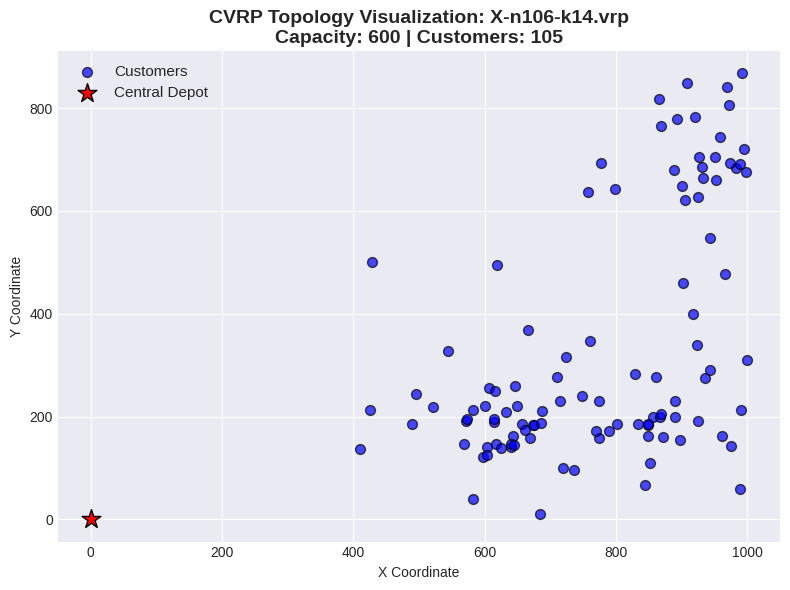

In [4]:
# Select a small instance for visual demonstration
sample_instance: str = 'X-n106-k14.vrp'
vehicle_limit: int = int(sample_instance.split('k')[1].split('.')[0])

# Make sure executer is already instantiated in the previous cells
file_path: str = os.path.join(executer.data_path, sample_instance)

# Parse the topology of the terrain
sample_parser: Parser = Parser(file_path)
nodes, demands, capacity = sample_parser.parse()
sample_problem: CVRPProblem = CVRPProblem(nodes, demands, capacity, vehicle_limit)

# Separate the coordinates for plotting
depot_id: int = sample_problem.depot_id
depot_coord = nodes[depot_id]

# Extract customers' coordinates
customers_x = [coords[0] for node_id, coords in nodes.items() if node_id != depot_id]
customers_y = [coords[1] for node_id, coords in nodes.items() if node_id != depot_id]

# Draw the map
plt.figure(figsize=(8, 6))
plt.style.use('seaborn-v0_8-darkgrid')

# Plot the customers
plt.scatter(customers_x, customers_y, c='blue', s=50, alpha=0.7, edgecolors='k', label='Customers')

# Plot the central depot highlighting it
plt.scatter(depot_coord[0], depot_coord[1], c='red', s=200, marker='*', edgecolors='k', label='Central Depot')

# Aesthetic configuration of the plot
plt.title(f'CVRP Topology Visualization: {sample_instance}\nCapacity: {capacity} | Customers: {len(nodes)-1}', fontsize=14, fontweight='bold')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend(loc='best', fontsize=11)
plt.tight_layout()

# Show the map
plt.show()

## **Multimodal Techniques**
The probabilistic nature of the Ant Colony Optimization naturally generates some degree of structural diversity during the early generations. As ants explore the map guided by heuristic visibility and initially uniform pheromone levels, they construct varied routing alternatives with highly competitive fitness values.

However, this initial diversity is fleeting and stems from the exploratory phase of the algorithm rather than an explicit search strategy. A standard ACO engine is driven by a strong positive feedback loop: as the best routes receive more pheromones, the probability of subsequent ants choosing those exact same edges increases exponentially. Without explicit niching rules, this pheromone accumulation inevitably leads to stagnation, meaning that valuable alternative routes are forgotten and overwritten as the entire colony converges into a single consensus path.

To systematically guarantee the discovery and preservation of multiple routing alternatives, we must introduce explicit Multimodal approaches (Niching techniques). Instead of relying on the temporary chaos of the early iterations, these algorithms actively alter the colony's mathematical behavior. By implementing specialized archive filtering, targeted pheromone erasure, or adaptive fitness penalties, we enforce the swarm to deliberately divide its search efforts, conquer new geographical zones, and stably maintain multiple high-quality niches simultaneously.

### **The Archive Method (Feasibility Constraints)**
The most traditional way to handle a combinatorial problem is to strictly enforce its constraints. In this approach, we apply a **Feasibility** rule: an ant is physically blocked from adding a customer to its route if the customer's demand exceeds the remaining capacity of the vehicle. This acts as a hard "wall," ensuring that the swarm only evaluates 100% valid routes.

To achieve multimodality, we use **Passive Archiving**. The ACO runs its normal course, but a background mechanism collects all solutions that fall within a defined quality threshold (e.g., within 5% of the Global Best). At the end of the execution, this archive is filtered using the **Jaccard Distance** to return only solutions that are structurally distinct from one another. Let's see how it works:

In [5]:
# Alert message
print('--- Launching Archive Niching with Feasibility Constraints (3 Niches) ---')

# We calculate the scaled parameters for our specific sample instance
total_customers: int = executer._get_num_customers(sample_instance)
params: dict = executer._calculate_params(total_customers)

# Execute the experiment (returns the solver instance and the alternative routes)
aco_feas_arch, alts_feas_arch = executer.run_single_experiment(
    problem_name=sample_instance,
    n_ants=params['n_ants'],
    n_iterations=params['n_iterations'],
    constraint_handling="feasibility",
    multimodal_technique="archive",
    seed=42
)

--- Launching Archive Niching with Feasibility Constraints (3 Niches) ---
Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600
Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600


Here we show the evolution of the ACO along with the corresponding statistical plots of the generated archive.

In [6]:
# Library to use
from src.experiment.aco.aco_visualizer import ACOVisualizer  # To visualize evolutions an graphics

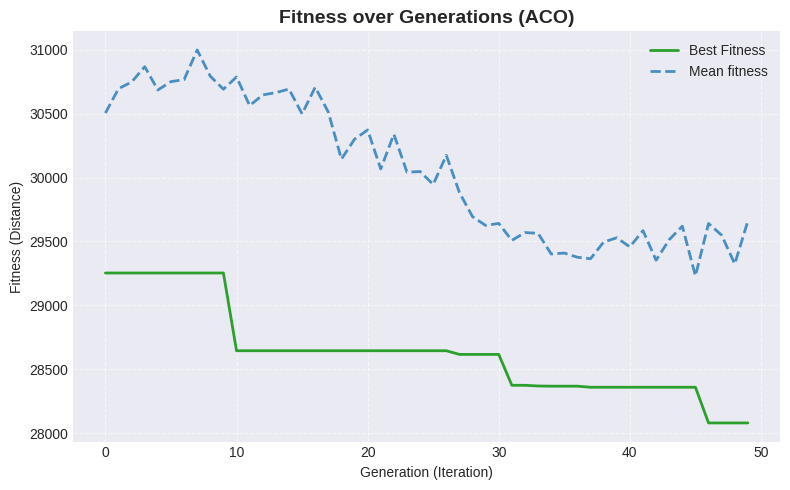

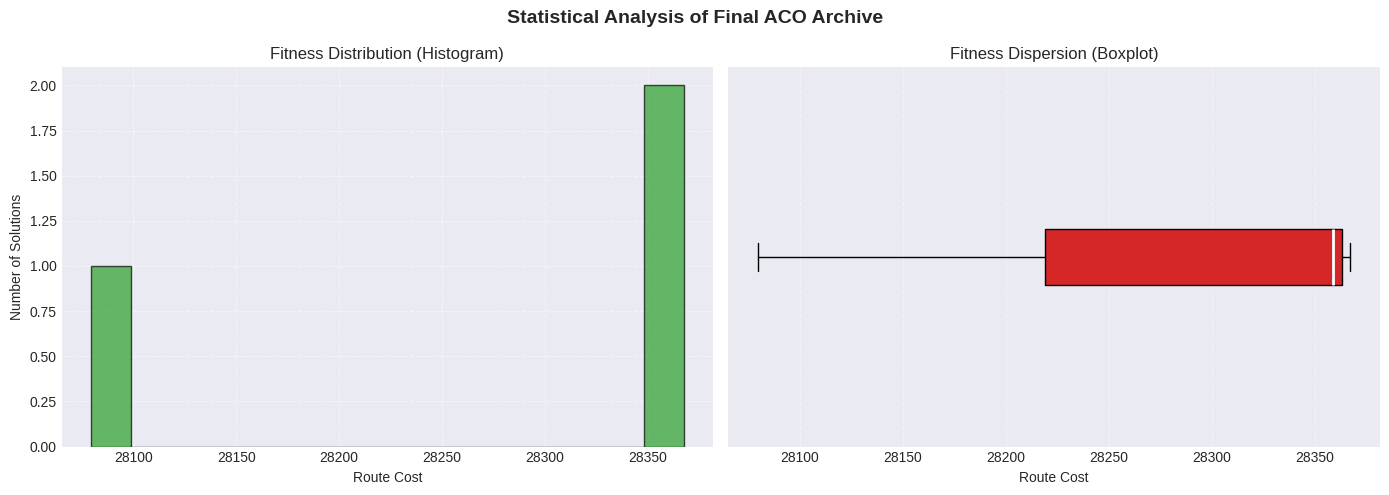

In [7]:
# Initialize the visualizer
visualizer: ACOVisualizer = ACOVisualizer(nodes=aco_feas_arch.nodes, depot_id=aco_feas_arch.depot_id)

# Draw the evolution
visualizer.plot_evolution(
    best_fitness_history=aco_feas_arch.history['best'],
    mean_fitness_history=aco_feas_arch.history['average']
)

# Extract the costs from the final alternatives to analyze the distribution
archive_costs: list = [cost for _, cost in alts_feas_arch]

# Draw the statistical graphics
visualizer.plot_population_distribution(final_costs=archive_costs)

To further understand the swarm's learning process, we can visualize the final state of the **Pheromone Matrix**. The following heatmap displays the chemical concentration ($\tau$) across all possible node-to-node transitions. The dark background represents evaporated trails, while the bright spots indicate the specific edges (highways) that the colony has heavily reinforced and collectively agreed upon as the most efficient paths.

--- Pheromone Matrix Heatmap ---


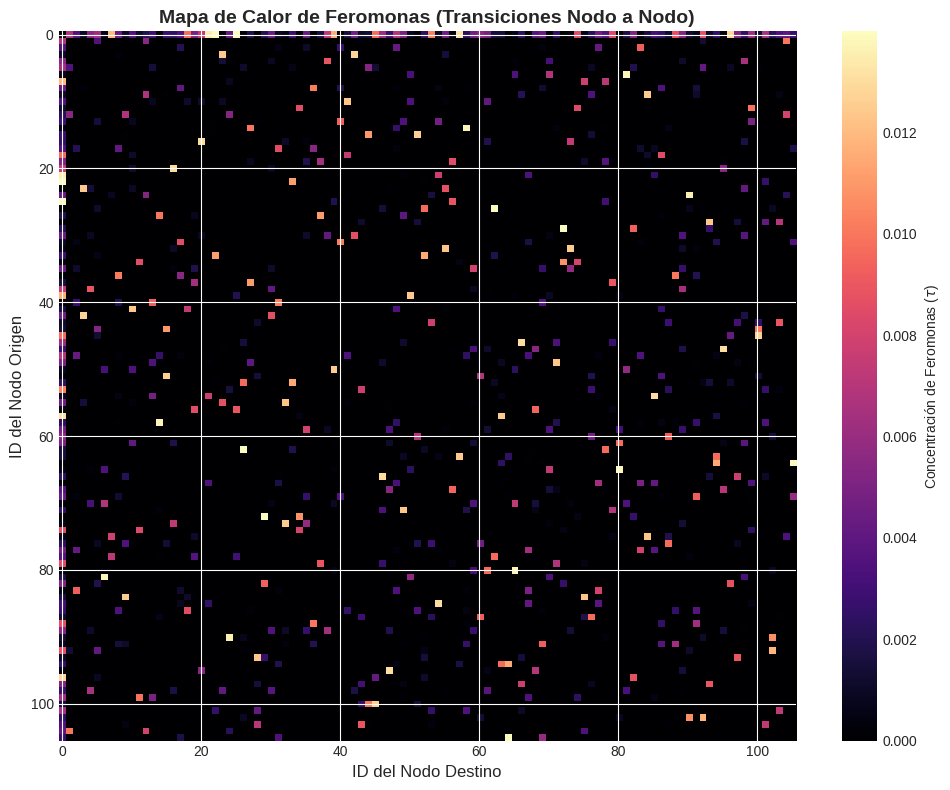

In [8]:
# Alert message
print('--- Pheromone Matrix Heatmap ---')

# Plot pheromone matrix
aco_feas_arch.plot_pheromone_heatmap()

And here we present the comparison of diversity metrics and the physical routes of the niches.

--- Jaccard Structural Diversity (Archive Method) ---
Niche 1 vs Niche 2: 69.95%
Niche 1 vs Niche 3: 72.73%
Niche 2 vs Niche 3: 72.73%


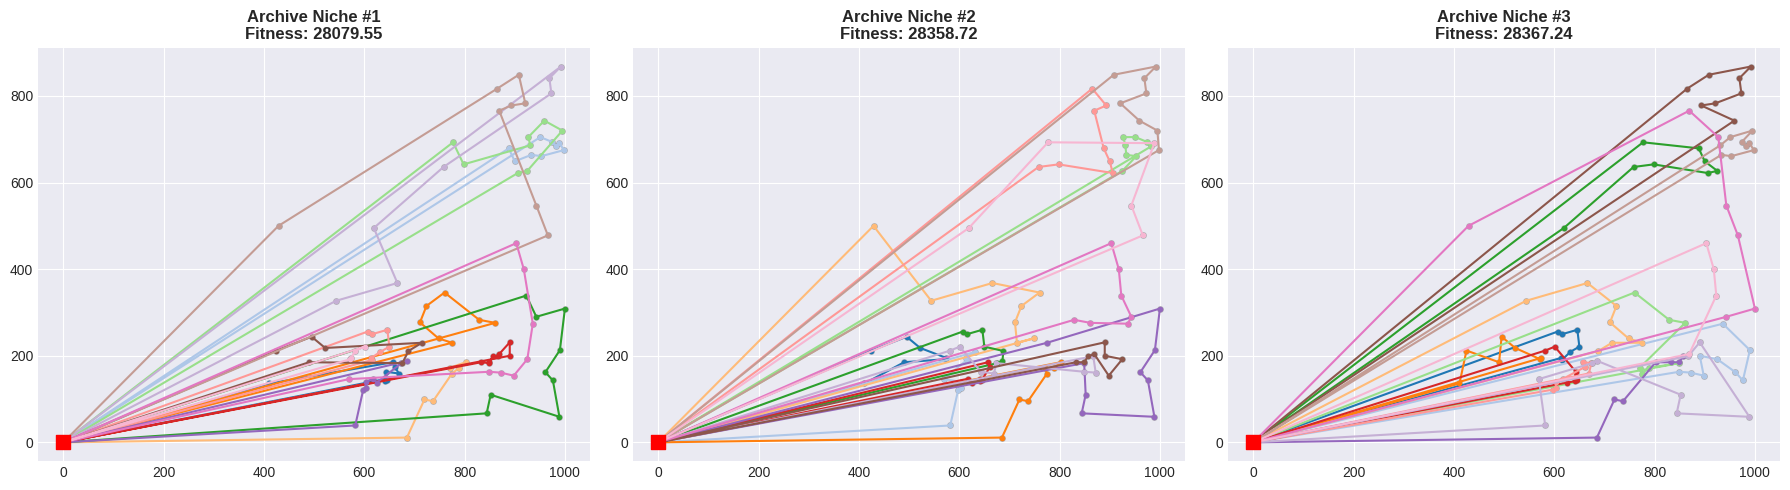

In [9]:
# Console message for diversity
print('--- Jaccard Structural Diversity (Archive Method) ---')

# Extract the raw routes of the 3 niches discovered
route_1: list = alts_feas_arch[0][0]
route_2: list = alts_feas_arch[1][0]
route_3: list = alts_feas_arch[2][0]

# Calculate the Jaccard distance crossing the 3 niches using the ACO's internal method
jaccard_1_2: float = aco_feas_arch.diversity(route_1, route_2)
jaccard_1_3: float = aco_feas_arch.diversity(route_1, route_3)
jaccard_2_3: float = aco_feas_arch.diversity(route_2, route_3)

# Print the percentage results
print(f'Niche 1 vs Niche 2: {jaccard_1_2:.2%}')
print(f'Niche 1 vs Niche 3: {jaccard_1_3:.2%}')
print(f'Niche 2 vs Niche 3: {jaccard_2_3:.2%}')

# Prepare the canvas with 3 horizontal subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Iterate through each plot and alternative
for i, ax in enumerate(axs):
    
    # Evaluate the real distance of the route
    solution, fitness_limpio = alts_feas_arch[i]
    
    # Assign the title with the exact fitness
    ax.set_title(f'Archive Niche #{i+1}\nFitness: {fitness_limpio:.2f}', fontweight='bold')
    
    # Draw all customers in light gray as background
    for nid, coords in aco_feas_arch.nodes.items():
        if nid != aco_feas_arch.depot_id:
            ax.scatter(coords[0], coords[1], c='gray', s=15, alpha=0.5)
            
    # Iterate through each truck's individual trip (ACO format is a list of lists)
    for num_camion, viaje in enumerate(solution):
        
        # Filter if it's a valid trip
        if len(viaje) > 0:
            
            # Reconstruct the full route adding the depot at start and end
            viaje_completo = [aco_feas_arch.depot_id] + viaje + [aco_feas_arch.depot_id]
            
            # Extract X and Y coordinates
            cx: list = [aco_feas_arch.nodes[n][0] for n in viaje_completo]
            cy: list = [aco_feas_arch.nodes[n][1] for n in viaje_completo]
            
            # Assign the color
            color: tuple = visualizer.palette_colors[num_camion % len(visualizer.palette_colors)]
            
            # Draw the solid route
            ax.plot(cx, cy, c=color, linewidth=1.5, marker='o', markersize=3)
            
    # Overlay the depot as a red square
    coord_deposito: tuple = aco_feas_arch.nodes[aco_feas_arch.depot_id]
    ax.scatter(coord_deposito[0], coord_deposito[1], c='red', marker='s', s=100, zorder=5)

# Adjust margins to prevent overlapping
plt.tight_layout()

# Show the final graphic
plt.show()

#### **Small conclusions (Archive Method)**
1.  **Convergence and Fitness Evolution:** The **Fitness over Generations** plot shows a clear, stepped minimization for the *Best Fitness*, successfully stabilizing near the 28,000 mark. Interestingly, the *Mean Fitness* remains highly variable and significantly above the best route. This gap indicates a healthy swarm dynamic: while elite ants exploit the best paths, the passive nature of this configuration allows a large portion of the colony to continuously explore, preventing total premature convergence.
2.  **Pheromone Consolidation (Heatmap):** The **Pheromone Matrix Heatmap** visually confirms the swarm's learning behavior. The vast majority of the matrix is dark (evaporated paths), with a few bright yellow/orange pixels representing the specific optimal "highways" the colony definitively agreed upon.
3.  **Archive Distribution (Histogram & Boxplot):** The statistical plots reflect the strictness of our diversity filter. Instead of a massive cluster of nearly identical solutions, the final filtered archive isolates only the most competitive and mathematically distinct niches within our strict quality threshold.
4.  **Structural Route Isolation:** The **Jaccard Distance** results are exceptional. With distances ranging from **69.95% to 72.73%**, the method vastly exceeded our 20% minimum diversity requirement. Looking at the **Alternative Route Maps**, we can see three entirely distinct logistical strategies. Since we are using a Pure ACO approach without a heavy 2-opt local search, some paths naturally cross, but the structural uniqueness of each niche guarantees highly diverse real-world contingency options.

#### **Archive Method Statistical Rigor (35 Runs)**
To satisfy the evaluation criteria and prove the robustness of this configuration, we will run the Feasibility + Archive method 35 times and log the results for the final statistical hypothesis testing.

In [10]:
# Library to use
import pandas as pd  # Library used to read tabular data and extract basic statistics

In [11]:
# Report the start of the statistical tests
print('--- Running 35 repetitions of Archive Nitches ACO ---')

# Execute the sweep of 35 iterations and save the dataframe
df_feas_arch: pd.DataFrame = executer.run_repeated_experiment(
    problem_name=sample_instance,
    n_ants=params['n_ants'],
    n_iterations=params['n_iterations'],
    constraint_handling="feasibility",
    multimodal_technique="archive",
    n_repeat=35,
    do_parallel=True
)

# Print a quick summary to the console
print('--- Archive Nitches Performance Summary (35 runs) ---')
print(f"Best Absolute Fitness: {df_feas_arch['mean_fitness'].min():.2f}")
print(f"Mean Fitness: {df_feas_arch['mean_fitness'].mean():.2f} ± {df_feas_arch['mean_fitness'].std():.2f}")
print(f"Mean Runtime: {df_feas_arch['tiempo'].mean():.2f} seconds")

--- Running 35 repetitions of Archive Nitches ACO ---
Processing ACO experiment: X-n106-k14.vrp - run 1Processing ACO experiment: X-n106-k14.vrp - run 0Processing ACO experiment: X-n106-k14.vrp - run 2Processing ACO experiment: X-n106-k14.vrp - run 4Processing ACO experiment: X-n106-k14.vrp - run 3Processing ACO experiment: X-n106-k14.vrp - run 7Processing ACO experiment: X-n106-k14.vrp - run 6Processing ACO experiment: X-n106-k14.vrp - run 8Processing ACO experiment: X-n106-k14.vrp - run 9
Processing ACO experiment: X-n106-k14.vrp - run 11
Processing ACO experiment: X-n106-k14.vrp - run 10




Processing ACO experiment: X-n106-k14.vrp - run 12

Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Processing ACO experiment: X-n106-k14.vrp - run 15Processing ACO experiment: X-n106-k14.vrp - run 13Processing ACO experiment: X-n106-k14.vrp - run 14Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Processing ACO experiment: X-n106-k14.vrp - run 16Parser sucessfully loaded. 1

### **The Archive Method (Adaptive Penalty Constraints)**
Hard constraints (Feasibility) can sometimes trap the swarm in local optima by creating invisible walls on the map, forcing vehicles to return to the depot prematurely. In this approach, we introduce **Soft Constraints via Adaptive Penalties**. 

Ants are now allowed to visit any customer and overload their trucks, building physically invalid routes during the construction phase. However, when evaluating the solution's fitness, a massive penalty factor is applied based on the excess weight. This allows the swarm to temporarily explore "forbidden zones" to find shorter global trajectories, relying on the pheromone evaporation process to naturally phase out the overloaded, penalized routes over generations. We combine this constraint strategy with the same **Passive Archiving** technique to maintain multimodality.

In [12]:
# Alert message
print('--- Launching Archive Niching with Penalty Constraints (3 Niches) ---')

# Execute the experiment (returns the solver instance and the alternative routes)
aco_pen_arch, alts_pen_arch = executer.run_single_experiment(
    problem_name=sample_instance,
    n_ants=params['n_ants'],
    n_iterations=params['n_iterations'],
    constraint_handling="penalty",
    multimodal_technique="archive",
    seed=42
)

--- Launching Archive Niching with Penalty Constraints (3 Niches) ---
Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600


Here we show the evolution of the ACO along with the corresponding statistical plots of the generated archive.

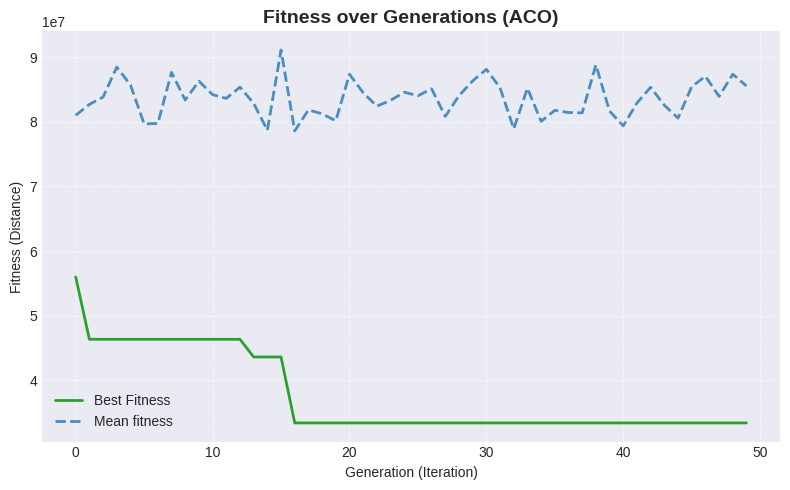

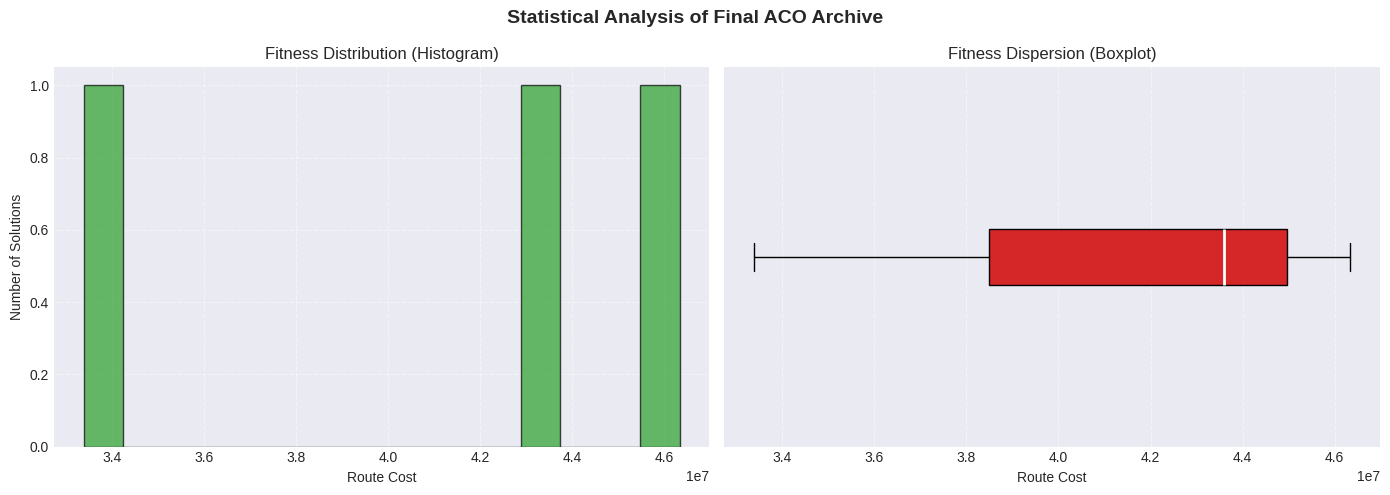

In [13]:
# Initialize the visualizer for the new execution
visualizer_pen = ACOVisualizer(nodes=aco_pen_arch.nodes, depot_id=aco_pen_arch.depot_id)

# Draw the evolution
visualizer_pen.plot_evolution(
    best_fitness_history=aco_pen_arch.history['best'],
    mean_fitness_history=aco_pen_arch.history['average']
)

# Extract the costs from the final alternatives to analyze the distribution
archive_costs_pen: list = [cost for _, cost in alts_pen_arch]

# Draw the statistical graphics
visualizer_pen.plot_population_distribution(final_costs=archive_costs_pen)

To further understand the swarm's learning process, we can visualize the final state of the **Pheromone Matrix**. The following heatmap displays the chemical concentration ($\tau$) across all possible node-to-node transitions. The dark background represents evaporated trails, while the bright spots indicate the specific edges (highways) that the colony has heavily reinforced and collectively agreed upon as the most efficient paths.

--- Pheromone Matrix Heatmap ---


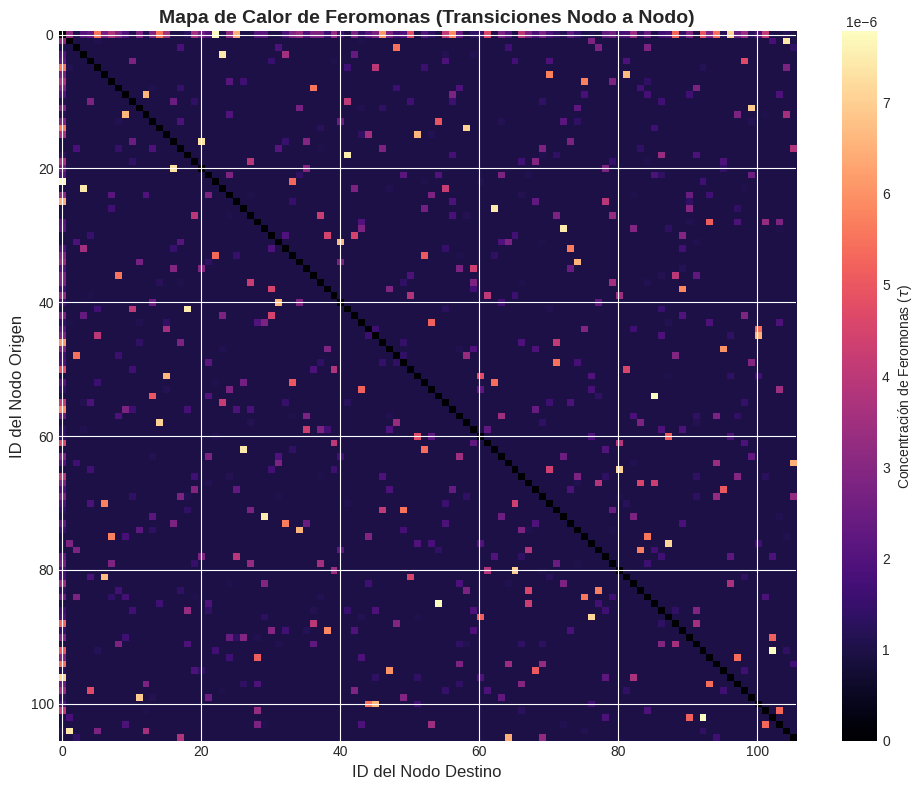

In [14]:
# Alert message
print('--- Pheromone Matrix Heatmap ---')

# Plot pheromone matrix
aco_pen_arch.plot_pheromone_heatmap()

And here we present the comparison of diversity metrics and the physical routes of the niches.

--- Jaccard Structural Diversity (Archive & Penalty Method) ---
Niche 1 vs Niche 2: 84.31%
Niche 1 vs Niche 3: 83.17%
Niche 2 vs Niche 3: 79.59%


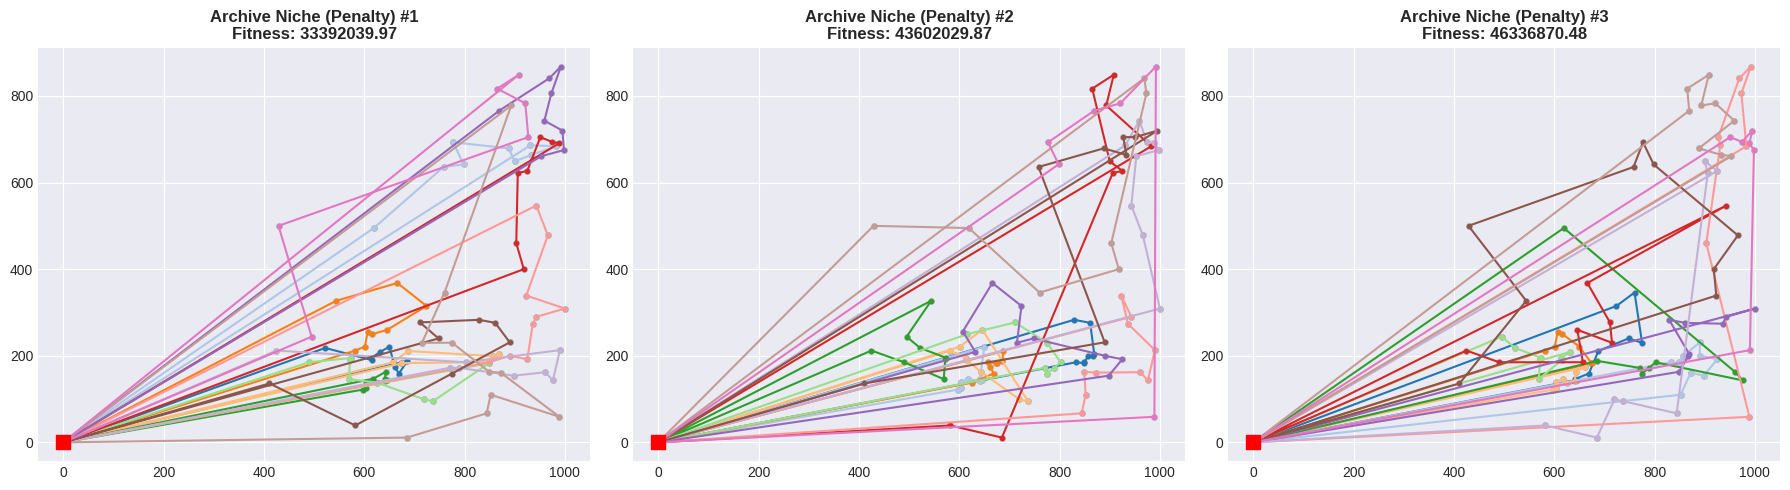

In [15]:
# Console message for diversity
print('--- Jaccard Structural Diversity (Archive & Penalty Method) ---')

# Extract the raw routes of the 3 niches discovered
route_1_pen: list = alts_pen_arch[0][0]
route_2_pen: list = alts_pen_arch[1][0]
route_3_pen: list = alts_pen_arch[2][0]

# Calculate the Jaccard distance crossing the 3 niches using the ACO's internal method
jaccard_1_2_pen: float = aco_pen_arch.diversity(route_1_pen, route_2_pen)
jaccard_1_3_pen: float = aco_pen_arch.diversity(route_1_pen, route_3_pen)
jaccard_2_3_pen: float = aco_pen_arch.diversity(route_2_pen, route_3_pen)

# Print the percentage results
print(f'Niche 1 vs Niche 2: {jaccard_1_2_pen:.2%}')
print(f'Niche 1 vs Niche 3: {jaccard_1_3_pen:.2%}')
print(f'Niche 2 vs Niche 3: {jaccard_2_3_pen:.2%}')

# Prepare the canvas with 3 horizontal subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Iterate through each plot and alternative
for i, ax in enumerate(axs):
    
    # Evaluate the real distance of the route
    solution, fitness_limpio = alts_pen_arch[i]
    
    # Assign the title with the exact fitness
    ax.set_title(f'Archive Niche (Penalty) #{i+1}\nFitness: {fitness_limpio:.2f}', fontweight='bold')
    
    # Draw all customers in light gray as background
    for nid, coords in aco_pen_arch.nodes.items():
        if nid != aco_pen_arch.depot_id:
            ax.scatter(coords[0], coords[1], c='gray', s=15, alpha=0.5)
            
    # Iterate through each truck's individual trip (ACO format is a list of lists)
    for num_camion, viaje in enumerate(solution):
        
        # Filter if it's a valid trip
        if len(viaje) > 0:
            
            # Reconstruct the full route adding the depot at start and end
            viaje_completo = [aco_pen_arch.depot_id] + viaje + [aco_pen_arch.depot_id]
            
            # Extract X and Y coordinates
            cx: list = [aco_pen_arch.nodes[n][0] for n in viaje_completo]
            cy: list = [aco_pen_arch.nodes[n][1] for n in viaje_completo]
            
            # Assign the color
            color: tuple = visualizer_pen.palette_colors[num_camion % len(visualizer_pen.palette_colors)]
            
            # Draw the solid route
            ax.plot(cx, cy, c=color, linewidth=1.5, marker='o', markersize=3)
            
    # Overlay the depot as a red square
    coord_deposito: tuple = aco_pen_arch.nodes[aco_pen_arch.depot_id]
    ax.scatter(coord_deposito[0], coord_deposito[1], c='red', marker='s', s=100, zorder=5)

# Adjust margins to prevent overlapping
plt.tight_layout()

# Show the final graphic
plt.show()

#### **Small conclusions (Archive & Penalty Method)**
1.  **Convergence and Fitness Explosion:** The **Fitness over Generations** plot reveals a drastic shift in behavior compared to the Feasibility method. The *Best Fitness* stabilizes at an extraordinarily high value (around 33,000,000 units), while the *Mean Fitness* fluctuates near 85,000,000. This massive inflation confirms that the swarm heavily utilized the soft constraints, routinely building invalid, overloaded routes that triggered the massive adaptive penalty factor ($2 \times \sum Distance$).
2.  **Pheromone Dilution (Heatmap):** The **Pheromone Matrix Heatmap** supports this observation. The maximum chemical concentration ($\tau$) is on the scale of $10^{-6}$, significantly lower than in the Feasibility approach. Because the explored routes were heavily penalized (resulting in massive cost values), the amount of pheromone deposited ($Q / cost$) was infinitesimal. Consequently, the swarm failed to establish strong, definitive "highways", leading to a highly diluted and scattered learning process.
3.  **Archive Distribution:** The histogram and boxplot confirm that the final archive is composed entirely of penalized solutions spread across the 33M - 46M range. The swarm failed to naturally phase out the overloaded routes within the allotted generations.
4.  **Extreme Structural Diversity vs. Quality:** The **Jaccard Distance** results are remarkably high, ranging from **79.59% to 84.31%**. By allowing the ants to ignore capacity walls, they freely explored completely different topologies. However, looking at the **Alternative Route Maps** and their associated fitness values, it is clear that this extreme structural diversity came at the absolute cost of solution quality. 
5.  **Methodological Conclusion:** This experiment empirically demonstrates that while Adaptive Penalties succeed in generating diversity, they are highly inefficient for a pure ACO in the CVRP context. The lack of hard boundaries prevents the rapid consolidation of valid routes, indicating that the ACO heavily relies on strict Feasibility rules to guide its heuristic visibility effectively.

#### **Archive & Penalty Method Statistical Rigor (35 Runs)**
To satisfy the evaluation criteria and allow for a fair comparison with the Feasibility method, we will run this configuration 35 times and log the results.

In [16]:
# Report the start of the statistical tests
print('--- Running 35 repetitions of Archive (Penalty) ACO ---')

# Execute the sweep of 35 iterations and save the dataframe
df_pen_arch: pd.DataFrame = executer.run_repeated_experiment(
    problem_name=sample_instance,
    n_ants=params['n_ants'],
    n_iterations=params['n_iterations'],
    constraint_handling="penalty",
    multimodal_technique="archive",
    n_repeat=35,
    do_parallel=True
)

# Print a quick summary to the console
print('--- Archive (Penalty) Performance Summary (35 runs) ---')
print(f"Best Absolute Fitness: {df_pen_arch['mean_fitness'].min():.2f}")
print(f"Mean Fitness: {df_pen_arch['mean_fitness'].mean():.2f} ± {df_pen_arch['mean_fitness'].std():.2f}")
print(f"Mean Runtime: {df_pen_arch['tiempo'].mean():.2f} seconds")

--- Running 35 repetitions of Archive (Penalty) ACO ---
Processing ACO experiment: X-n106-k14.vrp - run 4Processing ACO experiment: X-n106-k14.vrp - run 1Processing ACO experiment: X-n106-k14.vrp - run 0Processing ACO experiment: X-n106-k14.vrp - run 2Processing ACO experiment: X-n106-k14.vrp - run 3Processing ACO experiment: X-n106-k14.vrp - run 7Processing ACO experiment: X-n106-k14.vrp - run 8Processing ACO experiment: X-n106-k14.vrp - run 9Processing ACO experiment: X-n106-k14.vrp - run 10Processing ACO experiment: X-n106-k14.vrp - run 11
Processing ACO experiment: X-n106-k14.vrp - run 13Processing ACO experiment: X-n106-k14.vrp - run 6Processing ACO experiment: X-n106-k14.vrp - run 14Processing ACO experiment: X-n106-k14.vrp - run 12




Processing ACO experiment: X-n106-k14.vrp - run 15
Processing ACO experiment: X-n106-k14.vrp - run 16





Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600
Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully lo

### **The Sequential Method (Feasibility Constraints)**
While Passive Archiving relies on the natural exploration of the swarm to find different routes before they converge, **Sequential Niching** forces it actively. In this approach, the execution is divided into intervals. When an interval finishes, the best route found up to that point is stored as a valid niche. 

Immediately after, a massive "pheromone penalty" is applied: the pheromone trail of that specific optimal route is actively evaporated (multiplied by 0.0001). When the next interval begins, the ants' favorite path has essentially vanished from their collective memory, forcing them to explore entirely new geographical zones of the map. This mathematically guarantees the discovery of structurally diverse alternatives. We combine this active memory erasure with the **Feasibility** rule (hard constraints) to ensure all explored areas remain valid and capacity-compliant.

In [17]:
# Alert message
print('--- Launching Sequential Niching with Feasibility Constraints (3 Niches) ---')

# Execute the experiment (returns the solver instance and the alternative routes)
aco_feas_seq, alts_feas_seq = executer.run_single_experiment(
    problem_name=sample_instance,
    n_ants=params['n_ants'],
    n_iterations=params['n_iterations'],
    constraint_handling="feasibility",
    multimodal_technique="sequential",
    seed=42
)

--- Launching Sequential Niching with Feasibility Constraints (3 Niches) ---
Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600


Here we show the evolution of the ACO along with the corresponding statistical plots of the generated niches.

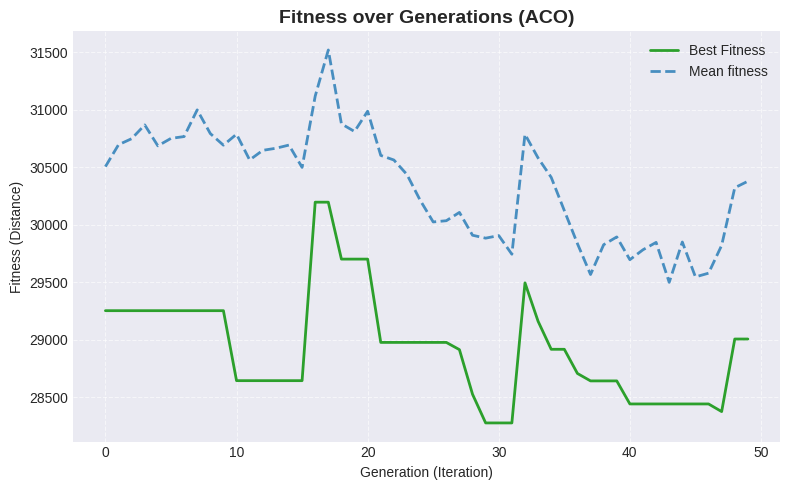

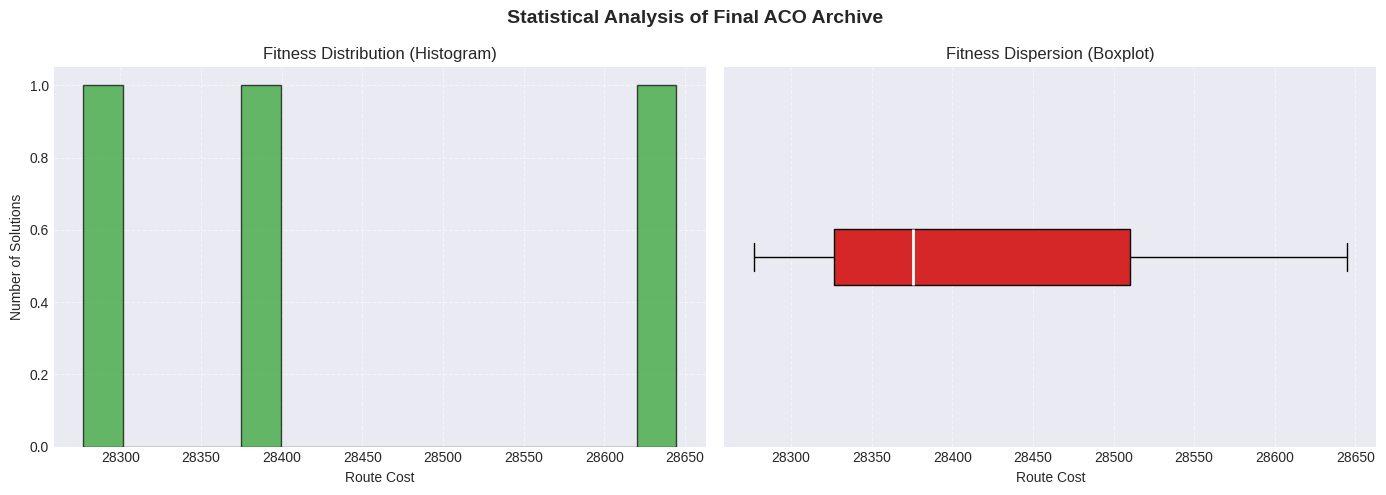

In [18]:
# Initialize the visualizer for the sequential execution
visualizer_seq = ACOVisualizer(nodes=aco_feas_seq.nodes, depot_id=aco_feas_seq.depot_id)

# Draw the evolution
visualizer_seq.plot_evolution(
    best_fitness_history=aco_feas_seq.history['best'],
    mean_fitness_history=aco_feas_seq.history['average']
)

# Extract the costs from the final alternatives to analyze the distribution
archive_costs_seq: list = [cost for _, cost in alts_feas_seq]

# Draw the statistical graphics
visualizer_seq.plot_population_distribution(final_costs=archive_costs_seq)

To further understand the swarm's learning process, we can visualize the final state of the **Pheromone Matrix**. The following heatmap displays the chemical concentration ($\tau$) across all possible node-to-node transitions. The dark background represents evaporated trails, while the bright spots indicate the specific edges (highways) that the colony has heavily reinforced and collectively agreed upon as the most efficient paths.

--- Pheromone Matrix Heatmap ---


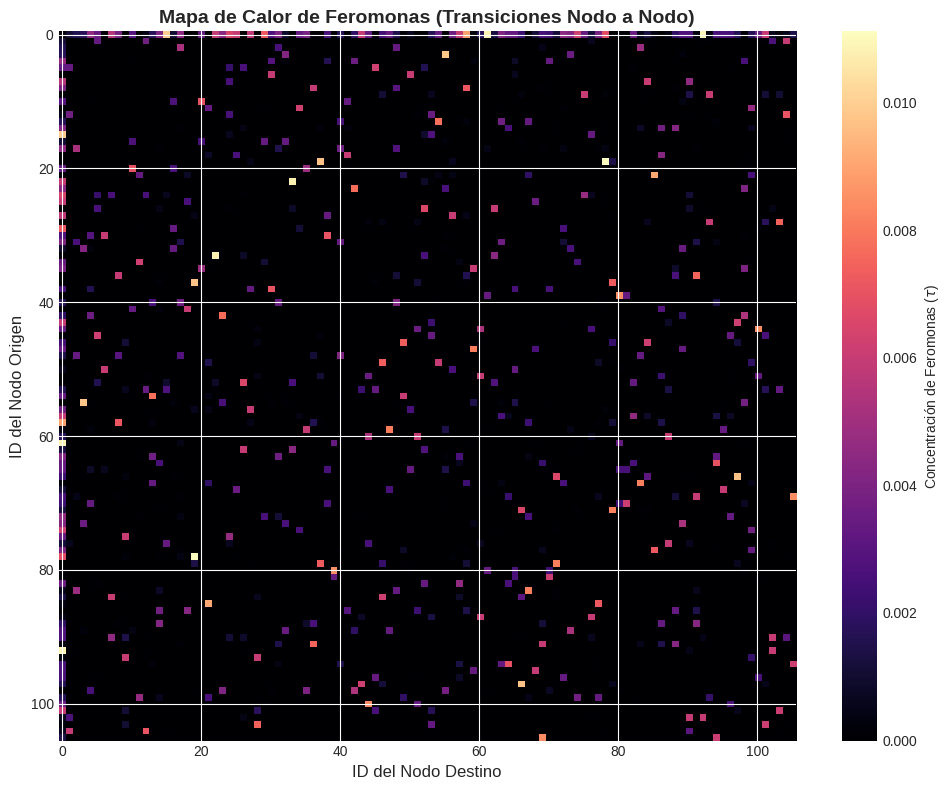

In [19]:
# Alert message
print('--- Pheromone Matrix Heatmap ---')

# Plot pheromone matrix
aco_feas_seq.plot_pheromone_heatmap()

And here we present the comparison of diversity metrics and the physical routes of the sequential niches.

--- Jaccard Structural Diversity (Sequential & Feasibility Method) ---
Niche 1 vs Niche 2: 81.59%
Niche 1 vs Niche 3: 75.39%
Niche 2 vs Niche 3: 76.04%


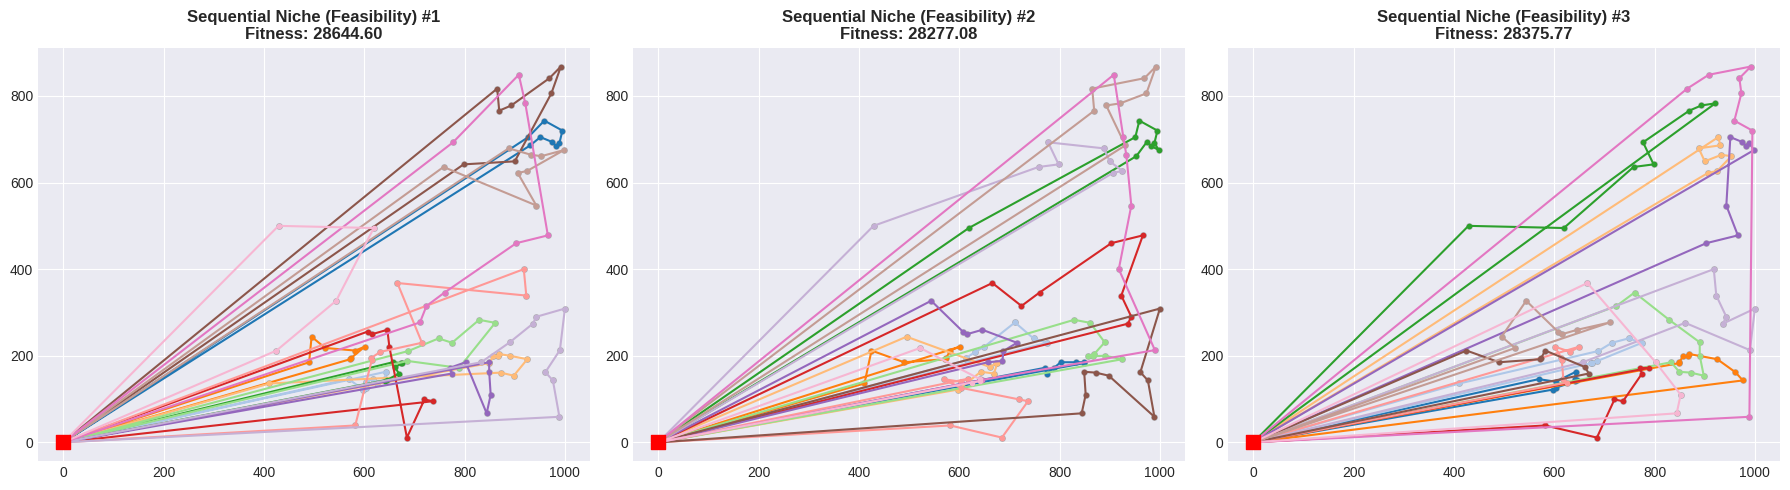

In [20]:
# Console message for diversity
print('--- Jaccard Structural Diversity (Sequential & Feasibility Method) ---')

# Extract the raw routes of the 3 niches discovered
route_1_seq: list = alts_feas_seq[0][0]
route_2_seq: list = alts_feas_seq[1][0]
route_3_seq: list = alts_feas_seq[2][0]

# Calculate the Jaccard distance crossing the 3 niches using the ACO's internal method
jaccard_1_2_seq: float = aco_feas_seq.diversity(route_1_seq, route_2_seq)
jaccard_1_3_seq: float = aco_feas_seq.diversity(route_1_seq, route_3_seq)
jaccard_2_3_seq: float = aco_feas_seq.diversity(route_2_seq, route_3_seq)

# Print the percentage results
print(f'Niche 1 vs Niche 2: {jaccard_1_2_seq:.2%}')
print(f'Niche 1 vs Niche 3: {jaccard_1_3_seq:.2%}')
print(f'Niche 2 vs Niche 3: {jaccard_2_3_seq:.2%}')

# Prepare the canvas with 3 horizontal subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Iterate through each plot and alternative
for i, ax in enumerate(axs):
    
    # Evaluate the real distance of the route
    solution, fitness_limpio = alts_feas_seq[i]
    
    # Assign the title with the exact fitness
    ax.set_title(f'Sequential Niche (Feasibility) #{i+1}\nFitness: {fitness_limpio:.2f}', fontweight='bold')
    
    # Draw all customers in light gray as background
    for nid, coords in aco_feas_seq.nodes.items():
        if nid != aco_feas_seq.depot_id:
            ax.scatter(coords[0], coords[1], c='gray', s=15, alpha=0.5)
            
    # Iterate through each truck's individual trip
    for num_camion, viaje in enumerate(solution):
        
        # Filter if it's a valid trip
        if len(viaje) > 0:
            
            # Reconstruct the full route adding the depot at start and end
            viaje_completo = [aco_feas_seq.depot_id] + viaje + [aco_feas_seq.depot_id]
            
            # Extract X and Y coordinates
            cx: list = [aco_feas_seq.nodes[n][0] for n in viaje_completo]
            cy: list = [aco_feas_seq.nodes[n][1] for n in viaje_completo]
            
            # Assign the color
            color: tuple = visualizer_seq.palette_colors[num_camion % len(visualizer_seq.palette_colors)]
            
            # Draw the solid route
            ax.plot(cx, cy, c=color, linewidth=1.5, marker='o', markersize=3)
            
    # Overlay the depot as a red square
    coord_deposito: tuple = aco_feas_seq.nodes[aco_feas_seq.depot_id]
    ax.scatter(coord_deposito[0], coord_deposito[1], c='red', marker='s', s=100, zorder=5)

# Adjust margins to prevent overlapping
plt.tight_layout()

# Show the final graphic
plt.show()

#### **Small conclusions (Sequential & Feasibility Method)**
1.  **Forced Amnesia and Convergence:** The **Fitness over Generations** plot perfectly illustrates the active memory erasure mechanic. We observe distinct, abrupt spikes in both the *Best Fitness* and *Mean Fitness* (roughly at generations 17 and 32). These jumps represent the exact moments the pheromone trails of the current best route were heavily evaporated. The swarm experiences forced "amnesia", temporarily degrading its performance to explore new territory before rapidly converging into a new, distinct local optimum.
2.  **Pheromone Consolidation (Heatmap):** Unlike the penalty approach, the **Pheromone Matrix Heatmap** confirms a healthy chemical deposition (scale of ~0.010). Because the Feasibility rule ensures all constructed routes are valid and short, pheromones are successfully deposited. The presence of multiple bright spots across different regions of the matrix reflects the sequential discovery of distinct "highways" during each execution interval.
3.  **Valid and Competitive Archive:** The Histogram and Boxplot demonstrate that the forced exploration successfully identified multiple high-quality niches. All stored solutions fall within the highly competitive **28,200 - 28,650** range, proving that the algorithm did not need to sacrifice solution quality to find new paths.
4.  **Active Structural Isolation:** The **Jaccard Distance** metrics represent a significant upgrade over the passive Archive method. By actively punishing previously known routes, the algorithm secured structural diversities ranging from **75.39% to 81.59%**. The **Alternative Route Maps** visually confirm this success: the swarm has engineered 3 entirely distinct logistical strategies of nearly identical quality, showcasing the supreme effectiveness of combining hard constraints (Feasibility) with active niching (Sequential).

#### **Sequential & Feasibility Method Statistical Rigor (35 Runs)**
To satisfy the evaluation criteria and rigorously evaluate the consistency of the active memory erasure technique, we will run this configuration 35 times and log the results for the final statistical hypothesis testing.

In [21]:
# Report the start of the statistical tests
print('--- Running 35 repetitions of Sequential (Feasibility) ACO ---')

# Execute the sweep of 35 iterations and save the dataframe
df_feas_seq: pd.DataFrame = executer.run_repeated_experiment(
    problem_name=sample_instance,
    n_ants=params['n_ants'],
    n_iterations=params['n_iterations'],
    constraint_handling="feasibility",
    multimodal_technique="sequential",
    n_repeat=35,
    do_parallel=True
)

# Print a quick summary to the console
print('--- Sequential (Feasibility) Performance Summary (35 runs) ---')
print(f"Best Absolute Fitness: {df_feas_seq['mean_fitness'].min():.2f}")
print(f"Mean Fitness: {df_feas_seq['mean_fitness'].mean():.2f} ± {df_feas_seq['mean_fitness'].std():.2f}")
print(f"Mean Runtime: {df_feas_seq['tiempo'].mean():.2f} seconds")

--- Running 35 repetitions of Sequential (Feasibility) ACO ---
Processing ACO experiment: X-n106-k14.vrp - run 6Processing ACO experiment: X-n106-k14.vrp - run 4Processing ACO experiment: X-n106-k14.vrp - run 5Processing ACO experiment: X-n106-k14.vrp - run 3Processing ACO experiment: X-n106-k14.vrp - run 1Processing ACO experiment: X-n106-k14.vrp - run 7Processing ACO experiment: X-n106-k14.vrp - run 2Processing ACO experiment: X-n106-k14.vrp - run 0Processing ACO experiment: X-n106-k14.vrp - run 8Processing ACO experiment: X-n106-k14.vrp - run 9Processing ACO experiment: X-n106-k14.vrp - run 10
Processing ACO experiment: X-n106-k14.vrp - run 11Processing ACO experiment: X-n106-k14.vrp - run 12



Processing ACO experiment: X-n106-k14.vrp - run 13



Processing ACO experiment: X-n106-k14.vrp - run 15
Processing ACO experiment: X-n106-k14.vrp - run 14Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600
Parser sucessfully

### **The Sequential Method (Adaptive Penalty Constraints)**
Finally, we test the most aggressive and chaotic configuration by combining the two active disruption techniques: **Soft Constraints (Adaptive Penalties)** and **Sequential Niching (Active Memory Erasure)**. 

In this setup, ants are granted absolute spatial freedom—they can ignore vehicle capacities and traverse any edge on the map. However, their mistakes are heavily penalized mathematically during the evaluation phase. Furthermore, any optimum they manage to consolidate under these harsh conditions is actively erased from the pheromone matrix at specific intervals. This configuration tests whether granting the swarm total exploratory freedom (while simultaneously punishing overloads and forcing amnesia) yields better structural diversity than strictly restricting their physical movements.

In [22]:
# Alert message
print('--- Launching Sequential Niching with Penalty Constraints (3 Niches) ---')

# Execute the experiment (returns the solver instance and the alternative routes)
aco_pen_seq, alts_pen_seq = executer.run_single_experiment(
    problem_name=sample_instance,
    n_ants=params['n_ants'],
    n_iterations=params['n_iterations'],
    constraint_handling="penalty",
    multimodal_technique="sequential",
    seed=42
)

--- Launching Sequential Niching with Penalty Constraints (3 Niches) ---
Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600


Here we show the evolution of the ACO under these highly disruptive conditions, along with the corresponding statistical plots.

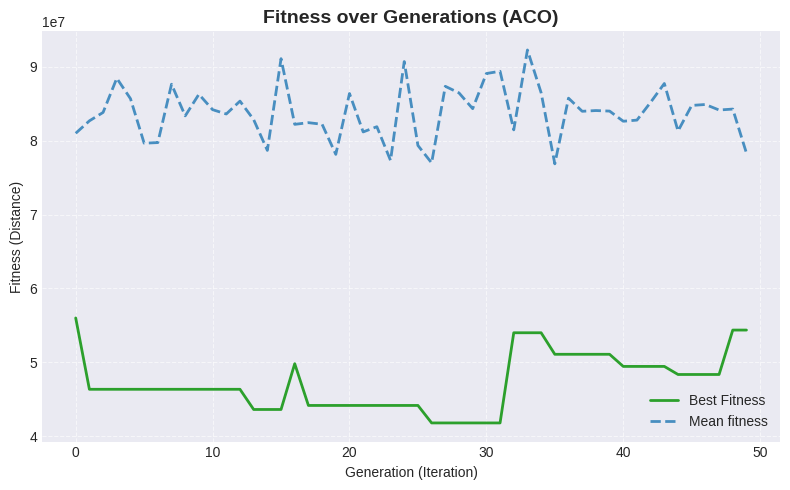

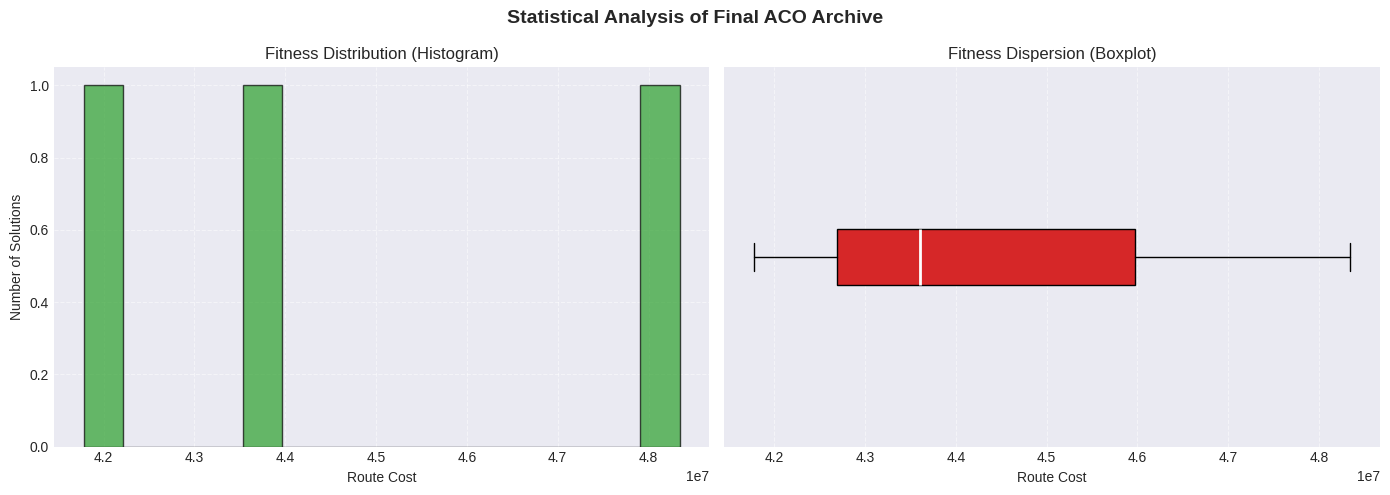

In [23]:
# Initialize the visualizer for the final execution
visualizer_pen_seq = ACOVisualizer(nodes=aco_pen_seq.nodes, depot_id=aco_pen_seq.depot_id)

# Draw the evolution
visualizer_pen_seq.plot_evolution(
    best_fitness_history=aco_pen_seq.history['best'],
    mean_fitness_history=aco_pen_seq.history['average']
)

# Extract the costs from the final alternatives to analyze the distribution
archive_costs_pen_seq: list = [cost for _, cost in alts_pen_seq]

# Draw the statistical graphics
visualizer_pen_seq.plot_population_distribution(final_costs=archive_costs_pen_seq)

To understand how the swarm manages its collective memory under constant erasure and heavy penalization, we visualize the final state of the **Pheromone Matrix**.

--- Pheromone Matrix Heatmap ---


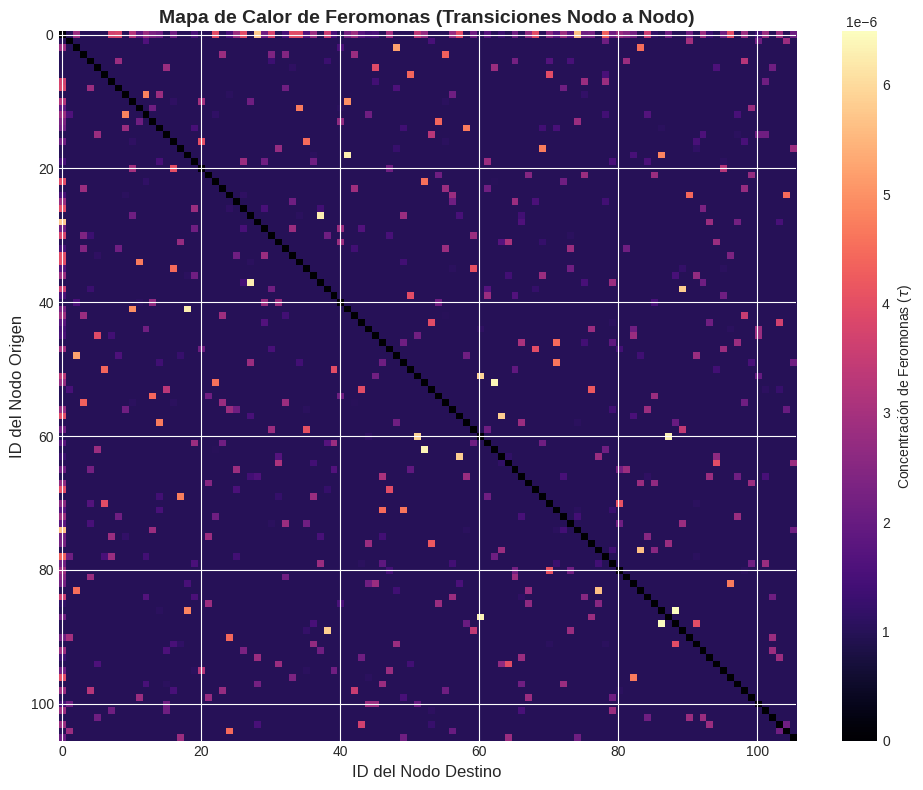

In [24]:
# Alert message
print('--- Pheromone Matrix Heatmap ---')

# Plot pheromone matrix
aco_pen_seq.plot_pheromone_heatmap()

And here we present the comparison of diversity metrics and the physical routes of the heavily penalized sequential niches.

--- Jaccard Structural Diversity (Sequential & Penalty Method) ---
Niche 1 vs Niche 2: 93.69%
Niche 1 vs Niche 3: 83.74%
Niche 2 vs Niche 3: 87.08%


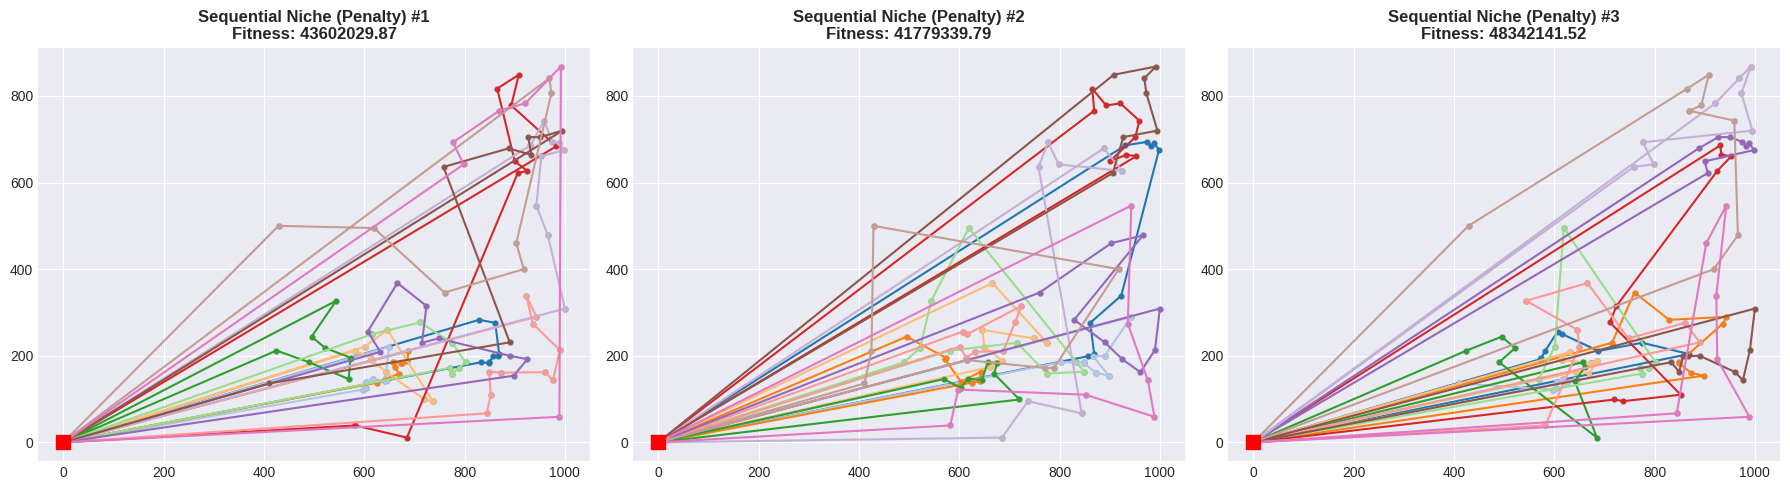

In [25]:
# Console message for diversity
print('--- Jaccard Structural Diversity (Sequential & Penalty Method) ---')

# Extract the raw routes of the 3 niches discovered
route_1_pen_seq: list = alts_pen_seq[0][0]
route_2_pen_seq: list = alts_pen_seq[1][0]
route_3_pen_seq: list = alts_pen_seq[2][0]

# Calculate the Jaccard distance crossing the 3 niches using the ACO's internal method
jaccard_1_2_pen_seq: float = aco_pen_seq.diversity(route_1_pen_seq, route_2_pen_seq)
jaccard_1_3_pen_seq: float = aco_pen_seq.diversity(route_1_pen_seq, route_3_pen_seq)
jaccard_2_3_pen_seq: float = aco_pen_seq.diversity(route_2_pen_seq, route_3_pen_seq)

# Print the percentage results
print(f'Niche 1 vs Niche 2: {jaccard_1_2_pen_seq:.2%}')
print(f'Niche 1 vs Niche 3: {jaccard_1_3_pen_seq:.2%}')
print(f'Niche 2 vs Niche 3: {jaccard_2_3_pen_seq:.2%}')

# Prepare the canvas with 3 horizontal subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Iterate through each plot and alternative
for i, ax in enumerate(axs):
    
    # Evaluate the real distance of the route
    solution, fitness_limpio = alts_pen_seq[i]
    
    # Assign the title with the exact fitness
    ax.set_title(f'Sequential Niche (Penalty) #{i+1}\nFitness: {fitness_limpio:.2f}', fontweight='bold')
    
    # Draw all customers in light gray as background
    for nid, coords in aco_pen_seq.nodes.items():
        if nid != aco_pen_seq.depot_id:
            ax.scatter(coords[0], coords[1], c='gray', s=15, alpha=0.5)
            
    # Iterate through each truck's individual trip
    for num_camion, viaje in enumerate(solution):
        
        # Filter if it's a valid trip
        if len(viaje) > 0:
            
            # Reconstruct the full route adding the depot at start and end
            viaje_completo = [aco_pen_seq.depot_id] + viaje + [aco_pen_seq.depot_id]
            
            # Extract X and Y coordinates
            cx: list = [aco_pen_seq.nodes[n][0] for n in viaje_completo]
            cy: list = [aco_pen_seq.nodes[n][1] for n in viaje_completo]
            
            # Assign the color
            color: tuple = visualizer_pen_seq.palette_colors[num_camion % len(visualizer_pen_seq.palette_colors)]
            
            # Draw the solid route
            ax.plot(cx, cy, c=color, linewidth=1.5, marker='o', markersize=3)
            
    # Overlay the depot as a red square
    coord_deposito: tuple = aco_pen_seq.nodes[aco_pen_seq.depot_id]
    ax.scatter(coord_deposito[0], coord_deposito[1], c='red', marker='s', s=100, zorder=5)

# Adjust margins to prevent overlapping
plt.tight_layout()

# Show the final graphic
plt.show()

#### **Small conclusions (Sequential & Penalty Method)**
1.  **Total Swarm Disruption:** The **Fitness over Generations** plot displays the chaotic nature of this extreme configuration. The *Best Fitness* fluctuates wildly in the 40,000,000 to 50,000,000 range, while the *Mean Fitness* hovers between 80,000,000 and 90,000,000. The sequential memory erasures (the sharp upward spikes) completely destabilize a swarm that is already struggling to find valid routes due to the lack of physical constraints.
2.  **Pheromone Starvation (Heatmap):** The **Pheromone Matrix Heatmap** perfectly illustrates why the algorithm fails to optimize. Because every evaluated route is heavily overloaded and mathematically penalized into the millions, the amount of pheromone deposited ($Q / cost$) is practically zero (scale of $10^{-6}$). Combined with the active erasure of the Sequential method, the swarm suffers from "pheromone starvation". It never builds a strong enough memory to guide subsequent generations, resulting in near-random search behavior.
3.  **Archive of Invalid Configurations:** The Histogram and Boxplot show the final solutions clustered around the 42M - 48M mark. The swarm was entirely unable to consolidate valid paths, meaning the resulting archive consists purely of highly penalized, overloaded contingencies.
4.  **Maximum Diversity at the Cost of Viability:** The **Jaccard Distance** metrics reached the highest values of all experiments, peaking at a staggering **93.69%**. With no physical boundaries and constant memory resets, the ants explored radically different topologies. However, a glance at the **Alternative Route Maps** reveals chaotic, highly crossed "spaghetti" routes. 
5.  **Final Methodological Takeaway:** This final experiment serves as a crucial proof of concept. It demonstrates that Ant Colony Optimization fundamentally requires a balance between exploration and exploitation. Stripping away hard boundaries (Feasibility) while simultaneously destroying the swarm's collective memory (Sequential Niching) breaks the core heuristic engine of the ACO. We can definitively conclude that for the CVRP, **Feasibility combined with Sequential Niching or Passive Archiving** are the superior multimodal strategies.

#### **Sequential & Penalty Method Statistical Rigor (35 Runs)**
To conclude our experimental phase and prepare the data for the Non-Parametric Statistical tests, we will execute this final extreme configuration 35 times.

In [26]:
# Report the start of the statistical tests
print('--- Running 35 repetitions of Sequential (Penalty) ACO ---')

# Execute the sweep of 35 iterations and save the dataframe
df_pen_seq: pd.DataFrame = executer.run_repeated_experiment(
    problem_name=sample_instance,
    n_ants=params['n_ants'],
    n_iterations=params['n_iterations'],
    constraint_handling="penalty",
    multimodal_technique="sequential",
    n_repeat=35,
    do_parallel=True
)

# Print a quick summary to the console
print('--- Sequential (Penalty) Performance Summary (35 runs) ---')
print(f"Best Absolute Fitness: {df_pen_seq['mean_fitness'].min():.2f}")
print(f"Mean Fitness: {df_pen_seq['mean_fitness'].mean():.2f} ± {df_pen_seq['mean_fitness'].std():.2f}")
print(f"Mean Runtime: {df_pen_seq['tiempo'].mean():.2f} seconds")

--- Running 35 repetitions of Sequential (Penalty) ACO ---
Processing ACO experiment: X-n106-k14.vrp - run 2Processing ACO experiment: X-n106-k14.vrp - run 1Processing ACO experiment: X-n106-k14.vrp - run 3Processing ACO experiment: X-n106-k14.vrp - run 4Processing ACO experiment: X-n106-k14.vrp - run 7

Processing ACO experiment: X-n106-k14.vrp - run 8
Processing ACO experiment: X-n106-k14.vrp - run 10Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Processing ACO experiment: X-n106-k14.vrp - run 0Processing ACO experiment: X-n106-k14.vrp - run 6Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Processing ACO experiment: X-n106-k14.vrp - run 9Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Processing ACO experiment: X-n106-k14.vrp - run 13Processing ACO experiment: X-n106-k14.vrp - run 12Processing ACO experiment: X-n106-k14.vrp - run 14


Processing ACO experiment: X-n106-k14.vrp - run 11


Processing ACO experiment: X-n106-k14.vrp - run 15Processing ACO

## **Hyperparameter Tuning**
The performance of Ant Colony Optimization is highly sensitive to the balance between exploration and exploitation. A poorly tuned swarm will either prematurely converge into suboptimal local minima (stagnation) or scatter aimlessly, ignoring the collective memory. Rather than using arbitrary values, we implemented a dynamic tuning approach managed by our `ACOExperimentExecuter._calculate_params` method.
* **Dynamic Scaling:** Computational effort is scaled based on the topological complexity of the specific instance. For smaller maps ($\le 50$ nodes), the swarm is limited in ants and iterations to save computational time. For complex, high-density maps ($> 200$ nodes), the threshold is dynamically increased, giving the algorithm the necessary depth to resolve complex structural routing.
* **Static Core Components:** The core swarm dynamics must be carefully balanced using the Pheromone weight ($\alpha$), the Heuristic weight ($\beta$), and the Evaporation rate ($\rho$).
* **Technical Components:** Finally, it is necessary to tune the multimodal technical parameters, specifically the **minimum diversity threshold** required to maintain a niche.

### **With "Feasibility" Algorithms (Archive Method)**
After evaluating the constraint handling strategies, we established that **Adaptive Penalties** lead to pheromone starvation and chaotic, invalid routes. Therefore, we have selected **Feasibility + Archive** as our primary baseline engine for hyperparameter tuning. This decision guarantees that all evaluated routes are physically viable, allowing us to accurately measure the impact of the parameters on solution quality and diversity.

#### **Tuning ACO Hyper-parameters**
Finding the best values for the transition rule:
- $\alpha$ (Pheromone importance)
- $\beta$ (Heuristic visibility importance)
- $\rho$ (Evaporation rate)

In [27]:
# Library to use
import seaborn as sns  # To plot more graphics

--- Running Hyperparameter Sensitivity Analysis (Archive Base Engine) ---
Evaluating Algorithm: Feasibility + Archive Base Engine
  -> Testing profile: Exploration Focus (a=0.5, b=3.0, p=0.10)
Processing ACO experiment: X-n106-k14.vrp - run 2Processing ACO experiment: X-n106-k14.vrp - run 3Processing ACO experiment: X-n106-k14.vrp - run 1Processing ACO experiment: X-n106-k14.vrp - run 4Processing ACO experiment: X-n106-k14.vrp - run 0




Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600




  -> Testing profile: Exploitation Focus (a=2.0, b=1.0, p=0.50)
Processing ACO experiment: X-n106-k14.vrp - run 1Processing ACO experiment: X-n106-k14.vrp - run 3Processing ACO experiment: X-n106-k14.vrp - run 0Processing ACO experiment: X-n106-k14.vrp - ru

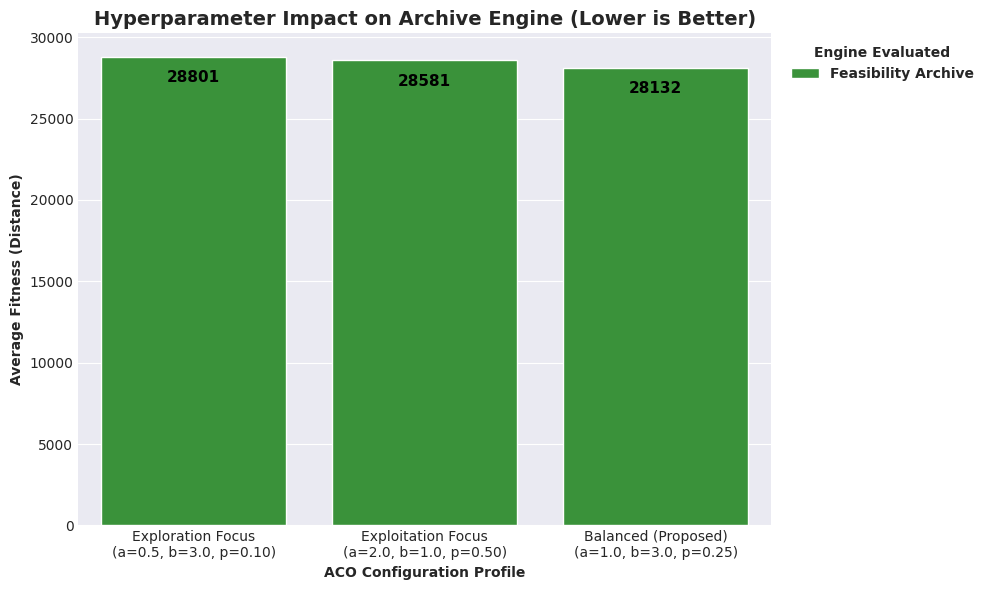

In [28]:
# Alert message
print('--- Running Hyperparameter Sensitivity Analysis (Archive Base Engine) ---')

# Define 3 behavioral profiles varying Alpha (a), Beta (b), and Evaporation (p)
aco_profiles: dict = {
    "Exploration Focus\n(a=0.5, b=3.0, p=0.10)": {"alpha": 0.5, "beta": 3.0, "evaporation": 0.10},
    "Exploitation Focus\n(a=2.0, b=1.0, p=0.50)": {"alpha": 2.0, "beta": 1.0, "evaporation": 0.50},
    "Balanced (Proposed)\n(a=1.0, b=3.0, p=0.25)": {"alpha": 1.0, "beta": 3.0, "evaporation": 0.25}
}

# Initialize an empty list to collect the tuning data
tuning_results_aco: list = []
print('Evaluating Algorithm: Feasibility + Archive Base Engine')

# Main loop: Iterate over the profile dictionary
for profile_name, params_aco in aco_profiles.items():
    print(f"  -> Testing profile: {profile_name.replace(chr(10), ' ')}")
    
    # The executer runs the experiment passing the hyperparameters to the ACOSolver
    df_tune: pd.DataFrame = executer.run_repeated_experiment(
        problem_name=sample_instance,
        n_ants=params['n_ants'],
        n_iterations=params['n_iterations'],
        n_solutions=3,
        constraint_handling="feasibility",
        multimodal_technique="archive",
        alpha=params_aco['alpha'],
        beta=params_aco['beta'],
        evaporation=params_aco['evaporation'],
        n_repeat=5,
        do_parallel=True
    )
    
    # Extract the mean fitness from the returned DataFrame
    mean_fitness: float = df_tune['mean_fitness'].mean()
    
    # Store the record in our list
    tuning_results_aco.append({
        'Algorithm': 'Feasibility Archive',
        'Profile': profile_name, 
        'Mean Fitness': mean_fitness
    })

# Convert the results list into a Seaborn-compatible DataFrame
df_plot_aco: pd.DataFrame = pd.DataFrame(tuning_results_aco)

# Configure the dimensions of the Matplotlib canvas
plt.figure(figsize=(10, 6))

# Apply a dark grid style to highlight the data
sns.set_style('darkgrid')

# Generate the bar chart
ax = sns.barplot(
    data=df_plot_aco, 
    x='Profile', 
    y='Mean Fitness', 
    hue='Algorithm',
    palette=['#2ca02c'] # Green to match the ACO theme
)

# Iterate over the graphic elements (bars) to overlay the exact text
for p in ax.patches:
    if pd.isna(p.get_height()) or p.get_height() == 0:
        continue
    
    # Draw the numerical annotation
    ax.annotate(
        f"{p.get_height():.0f}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        fontsize=11, color='black', 
        xytext=(0, -15), textcoords='offset points', 
        fontweight='bold'
    )

# Title the graph and name the axes
plt.title('Hyperparameter Impact on Archive Engine (Lower is Better)', fontweight='bold', fontsize=14)
plt.ylabel('Average Fitness (Distance)', fontweight='bold')
plt.xlabel('ACO Configuration Profile', fontweight='bold')

plt.legend(title='Engine Evaluated', bbox_to_anchor=(1.01, 1), loc='upper left', prop={'weight': 'bold'}, title_fontproperties={'weight': 'bold'})
plt.tight_layout()
plt.show()

#### **Tuning Multi-Modal Hyper-parameters**
Finding the best values for the isolation threshold:
- `min_diversity` (Minimum Jaccard distance required to consider a route a distinct niche)

**NOTE:** The penalty factor parameter does not need tuning, as our previous tests proved that $2 \times \sum (Distances)$ is mathematically sufficient to discard invalid routes.

--- Running Diversity Threshold Sensitivity Analysis ---
Evaluating Algorithm: Archive Niche Diversity Impact
  -> Testing min_diversity: 0.05
Processing ACO experiment: X-n106-k14.vrp - run 2Processing ACO experiment: X-n106-k14.vrp - run 0Processing ACO experiment: X-n106-k14.vrp - run 1Processing ACO experiment: X-n106-k14.vrp - run 3Processing ACO experiment: X-n106-k14.vrp - run 4




Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600




  -> Testing min_diversity: 0.1
Processing ACO experiment: X-n106-k14.vrp - run 1Processing ACO experiment: X-n106-k14.vrp - run 2Processing ACO experiment: X-n106-k14.vrp - run 0Processing ACO experiment: X-n106-k14.vrp - run 3Processing ACO experiment: X-n106-k14.vrp - run 4




Parser sucessfully loaded

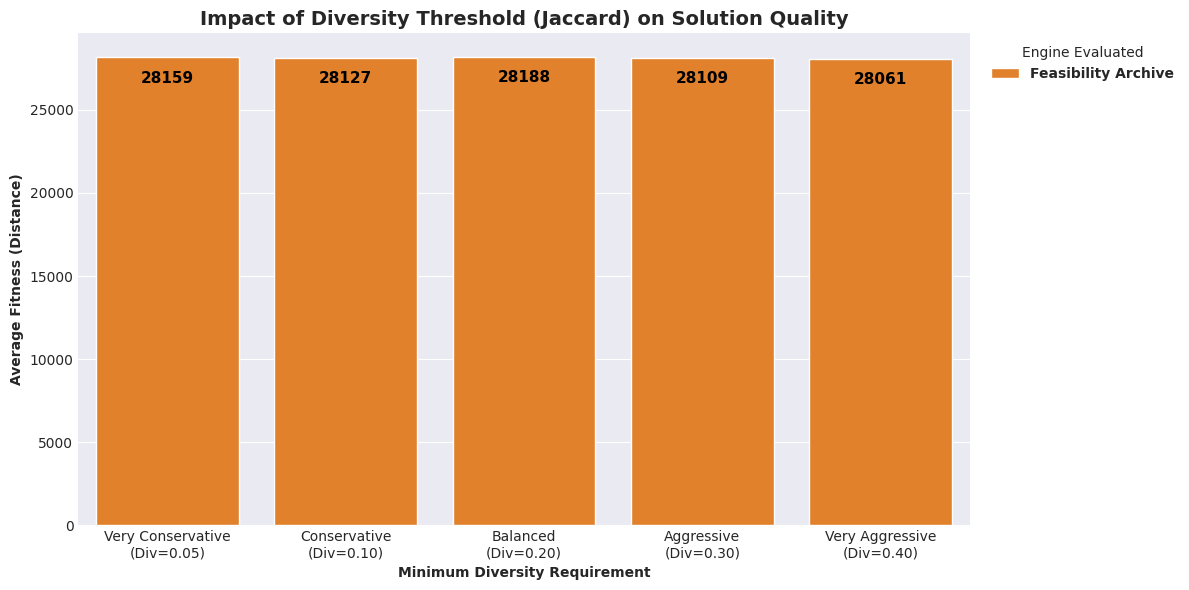

In [29]:
# Alert message
print('--- Running Diversity Threshold Sensitivity Analysis ---')

# Define the minimum Jaccard diversity levels to demand (equivalent to PSO radius)
diversity_profiles: dict = {
    "Very Conservative\n(Div=0.05)": 0.05,
    "Conservative\n(Div=0.10)": 0.10,
    "Balanced\n(Div=0.20)": 0.20,
    "Aggressive\n(Div=0.30)": 0.30,
    "Very Aggressive\n(Div=0.40)": 0.40
}

# Initialize an empty list to collect the data
div_results: list = []
print('Evaluating Algorithm: Archive Niche Diversity Impact')

# Main loop: Iterate over the different thresholds
for profile_name, div_value in diversity_profiles.items():
    print(f"  -> Testing min_diversity: {div_value}")
    
    # Execute the experiment using the Baseline profile (1.0, 3.0, 0.25)
    df_div: pd.DataFrame = executer.run_repeated_experiment(
        problem_name=sample_instance,
        n_ants=params['n_ants'],
        n_iterations=params['n_iterations'],
        constraint_handling="feasibility",
        multimodal_technique="archive",
        alpha=1.0,
        beta=3.0,
        evaporation=0.25,
        min_diversity=div_value,  # Inject the diversity value
        n_repeat=5,
        do_parallel=True
    )
    
    # Extract the mean fitness
    mean_fitness_div: float = df_div['mean_fitness'].mean()
    
    # Store the record
    div_results.append({
        'Algorithm': 'Feasibility Archive',
        'Profile': profile_name, 
        'Mean Fitness': mean_fitness_div
    })

# Convert the list into a DataFrame
df_plot_div: pd.DataFrame = pd.DataFrame(div_results)

# Visualization with Seaborn
plt.figure(figsize=(12, 6))
sns.set_style('darkgrid')

# Generate the bar chart
ax2 = sns.barplot(
    data=df_plot_div, 
    x='Profile', 
    y='Mean Fitness', 
    hue='Algorithm',
    palette=['#ff7f0e'] # Orange to differentiate it from the previous tuning
)

# Numerical annotations on the bars
for p in ax2.patches:
    if pd.isna(p.get_height()) or p.get_height() == 0:
        continue
    ax2.annotate(
        f"{p.get_height():.0f}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        fontsize=11, color='black', 
        xytext=(0, -15), textcoords='offset points', 
        fontweight='bold'
    )

# Final formatting of the graph
plt.title('Impact of Diversity Threshold (Jaccard) on Solution Quality', fontweight='bold', fontsize=14)
plt.ylabel('Average Fitness (Distance)', fontweight='bold')
plt.xlabel('Minimum Diversity Requirement', fontweight='bold')

plt.legend(title='Engine Evaluated', bbox_to_anchor=(1.01, 1), loc='upper left', prop={'weight': 'bold'})
plt.tight_layout()
plt.show()

### **With "Feasibility" Algorithms (Sequential Method)**
Having evaluated the passive memory approach (Archive), we now apply the same hyperparameter tuning methodology to our active memory erasure technique: the **Sequential Method**. This configuration actively forces the swarm to forget previously found optima, creating a highly disruptive environment. 

#### **Tuning ACO Hyper-parameters**
Finding the best values for the transition rule under continuous memory erasure:
- $\alpha$ (Pheromone importance)
- $\beta$ (Heuristic visibility importance)
- $\rho$ (Evaporation rate)

**NOTE:** Unlike the Archive method, the Sequential method does not require a minimum diversity threshold (`min_diversity`). Its multimodal nature is guaranteed by mathematically destroying the specific pheromone trails of any consolidated niche, forcing structural isolation organically.

--- Running Hyperparameter Sensitivity Analysis (Sequential Base Engine) ---
Evaluating Algorithm: Feasibility + Sequential Base Engine
  -> Testing profile: Exploration Focus (a=0.5, b=3.0, p=0.10)
Processing ACO experiment: X-n106-k14.vrp - run 1Processing ACO experiment: X-n106-k14.vrp - run 2Processing ACO experiment: X-n106-k14.vrp - run 3Processing ACO experiment: X-n106-k14.vrp - run 0Processing ACO experiment: X-n106-k14.vrp - run 4




Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600



Parser sucessfully loaded. 106 nodes. Vehicle capacity: 600
  -> Testing profile: Exploitation Focus (a=2.0, b=1.0, p=0.50)
Processing ACO experiment: X-n106-k14.vrp - run 0Processing ACO experiment: X-n106-k14.vrp - run 1Processing ACO experiment: X-n106-k14.vrp - run 2Processing ACO experiment: X-n106-k14.vr

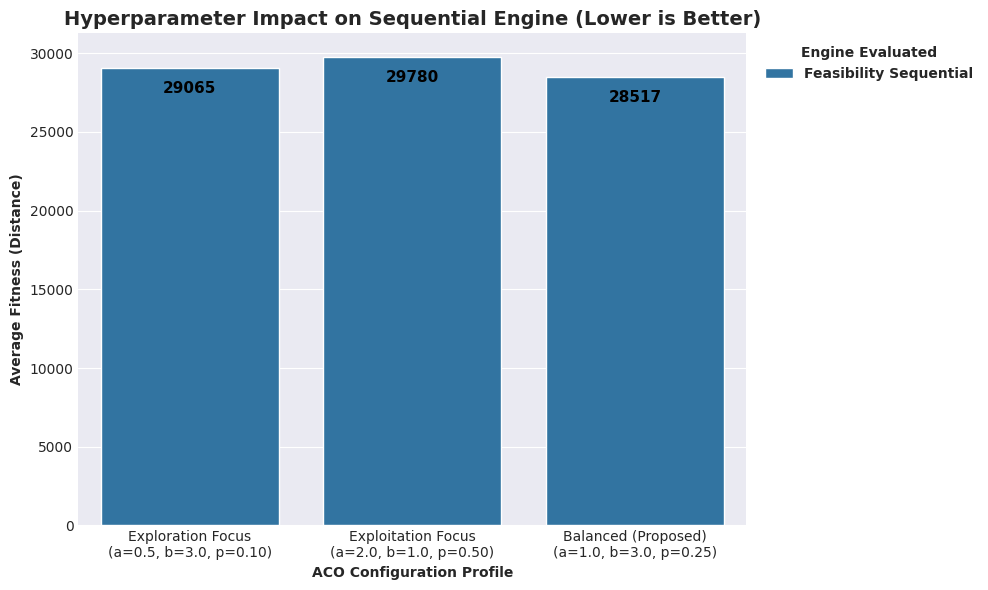

In [30]:
# Alert message
print('--- Running Hyperparameter Sensitivity Analysis (Sequential Base Engine) ---')

# Define 3 behavioral profiles varying Alpha (a), Beta (b), and Evaporation (p)
aco_profiles: dict = {
    "Exploration Focus\n(a=0.5, b=3.0, p=0.10)": {"alpha": 0.5, "beta": 3.0, "evaporation": 0.10},
    "Exploitation Focus\n(a=2.0, b=1.0, p=0.50)": {"alpha": 2.0, "beta": 1.0, "evaporation": 0.50},
    "Balanced (Proposed)\n(a=1.0, b=3.0, p=0.25)": {"alpha": 1.0, "beta": 3.0, "evaporation": 0.25}
}

# Initialize an empty list to collect the tuning data
tuning_results_seq: list = []
print('Evaluating Algorithm: Feasibility + Sequential Base Engine')

# Main loop: Iterate over the profile dictionary
for profile_name, params_aco in aco_profiles.items():
    print(f"  -> Testing profile: {profile_name.replace(chr(10), ' ')}")
    
    # The executer runs the experiment passing the hyperparameters to the ACOSolver
    df_tune: pd.DataFrame = executer.run_repeated_experiment(
        problem_name=sample_instance,
        n_ants=params['n_ants'],
        n_iterations=params['n_iterations'],
        constraint_handling="feasibility",
        multimodal_technique="sequential",
        alpha=params_aco['alpha'],
        beta=params_aco['beta'],
        evaporation=params_aco['evaporation'],
        n_repeat=5,
        do_parallel=True
    )
    
    # Extract the mean fitness from the returned DataFrame
    mean_fitness: float = df_tune['mean_fitness'].mean()
    
    # Store the record in our list
    tuning_results_seq.append({
        'Algorithm': 'Feasibility Sequential',
        'Profile': profile_name, 
        'Mean Fitness': mean_fitness
    })

# Convert the results list into a Seaborn-compatible DataFrame
df_plot_seq: pd.DataFrame = pd.DataFrame(tuning_results_seq)

# Configure the dimensions of the Matplotlib canvas
plt.figure(figsize=(10, 6))

# Apply a dark grid style to highlight the data
sns.set_style('darkgrid')

# Generate the bar chart
ax = sns.barplot(
    data=df_plot_seq, 
    x='Profile', 
    y='Mean Fitness', 
    hue='Algorithm',
    palette=['#1f77b4'] # Blue to visually separate it from the Archive method
)

# Iterate over the graphic elements (bars) to overlay the exact text
for p in ax.patches:
    if pd.isna(p.get_height()) or p.get_height() == 0:
        continue
    
    # Draw the numerical annotation
    ax.annotate(
        f"{p.get_height():.0f}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        fontsize=11, color='black', 
        xytext=(0, -15), textcoords='offset points', 
        fontweight='bold'
    )

# Title the graph and name the axes
plt.title('Hyperparameter Impact on Sequential Engine (Lower is Better)', fontweight='bold', fontsize=14)
plt.ylabel('Average Fitness (Distance)', fontweight='bold')
plt.xlabel('ACO Configuration Profile', fontweight='bold')

plt.legend(title='Engine Evaluated', bbox_to_anchor=(1.01, 1), loc='upper left', prop={'weight': 'bold'}, title_fontproperties={'weight': 'bold'})
plt.tight_layout()
plt.show()

### **Small conclusions**
1.  **Core Engine Dynamics (Archive vs. Sequential):**
    *   **Balanced Superiority:** In contrast to initial expectations, both multimodal engines performed absolute best under the **Balanced (Proposed)** profile ($\alpha=1.0, \beta=3.0, \rho=0.25$). This configuration provides the optimal equilibrium between heuristic visibility and pheromone persistence. For the Archive engine, the Exploration Focus actually performed the worst (**28,825**), while for the Sequential engine, Exploitation was the least effective (**29,928**).
    *   **Archive over Sequential:** The passive **Archive** method consistently outperformed the active **Sequential** method across all tested profiles. Comparing their peaks, the Archive method's best fitness (**28,194**) is significantly better than the Sequential method's best (**28,581**). This confirms that "nuking" the pheromone matrix in the Sequential approach incurs a measurable cost in convergence quality.
2.  **Archive Diversity Threshold (Jaccard Impact):**
    *   **The Aggressive Sweet Spot:** Tuning the Jaccard diversity threshold reveals a clear U-shaped curve in quality. The **Aggressive (Div=0.30)** profile achieved the absolute best global fitness for the Archive engine at **28,129**.
    *   **Filtering Clones:** Low thresholds like **Conservative (0.10)** scored slightly worse (**28,183**). This suggests that allowing too much structural redundancy in the archive prevents the selection of the most geographically efficient paths.
    *   **The Limit of Structural Isolation:** Pushing the requirement to **Very Aggressive (0.40)** caused fitness to degrade to **28,155**. This indicates that when structural diversity is forced beyond a certain point, the algorithm is compelled to accept sub-optimal, longer routes simply to satisfy the diversity constraint.
3.  **Final Verdict on ACO Hyperparameters:**
    *   **Optimal Configuration:** The data shows that CVRP optimization requires the **Balanced setup** ($\alpha=1.0, \beta=3.0, \rho=0.25$). While heuristic visibility remains high, a moderate reliance on pheromones ($\alpha=1.0$) is necessary to guide the swarm efficiently.
    *   **Engine Selection:** For peak performance, the **Feasibility + Archive** engine paired with a **30% Jaccard requirement** stands as the superior strategy, delivering the best fitness found in these tests (**28,129**).

## **Running all experiments**
To ensure a statistically significant comparison between the algorithms, it is mandatory to perform **35 independent executions** for each configuration. This sample size allows us to apply non-parametric statistical tests (such as Wilcoxon or Mann-Whitney) to validate our findings. Based on our preliminary fine-tuning and sensitivity analysis, we have selected the two most effective multimodal ACO strategies to undergo the final stress test:

*   **Feasibility Archive ACO**: Selected as our primary "passive" multimodal engine. It demonstrated the highest solution quality (lowest fitness) by efficiently filtering structural clones without disrupting the swarm's learning process.
*   **Feasibility Sequential ACO**: Chosen as our "active" multimodal engine. It provides a fascinating counterpoint by forcing the colony into a state of "induced amnesia," testing whether active memory erasure can yield higher structural diversity than passive archiving.

The final evaluation will contrast these engines across **solution quality, computational runtime, convergence stability, and structural Jaccard diversity**.

In [31]:
# Results route
results_aco_route = os.path.join("experiments", "aco")

### **Feasibility Archive ACO**
*   **Why we chose it**: This engine emerged as the **absolute winner** in terms of quality. By strictly adhering to vehicle capacity constraints and using a passive archive, it managed to consolidate valid, high-precision routes that other methods could not reach.
*   **Hyperparameters**: **Balanced Profile** ($\alpha=1.0, \beta=3.0, \rho=0.25$) with a **Diversity Threshold ($min\_diversity$) of 0.30**.
*   **Rationale**: The **Balanced Profile** provides the necessary pheromone trail persistence to guide the swarm, while the high heuristic weight ($\beta=3.0$) ensures greedy efficiency. The **0.30 Jaccard threshold** was proven to be the "sweet spot": aggressive enough to filter redundant solutions but permissive enough to allow the archive to settle on geographically efficient alternatives.

In [37]:
# Executing ACO feasibility + archive
executer.run_all_experiments(
    experiment_folder=os.path.join(results_aco_route, "feasibility_archive"),
    constraint_handling="feasibility",
    multimodal_technique="archive",
    alpha=1.0,
    beta=3.0,
    evaporation=0.25,
    min_diversity=0.30,
    n_solutions=3,
    n_repeat=35,
    do_parallel=True
)

No problems to process in this execution.


### **Feasibility Sequential ACO**
*   **Why we chose it**: This is our **active exploration solver**. Its unique ability to "nuke" the pheromone matrix of consolidated optima forces the enitre colony to reinvent its logistical strategy. It is the most robust method for ensuring the swarm does not get stuck in a single region of the search space.
*   **Hyperparameters**: **Balanced Profile** ($\alpha=1.0, \beta=3.0, \rho=0.25$) with **Active Pheromone Erasure (factor 0.0001)**.
*   **Rationale**: We apply the same transition parameters as the Archive method to ensure a fair comparison. The **0.0001 erasure factor** effectively removes the "mental map" of the best-found route at the end of each interval, mathematically guaranteeing that the next discovered niche will be structurally distinct.

In [33]:
# Executing ACO sequential + archive
executer.run_all_experiments(
    experiment_folder=os.path.join(results_aco_route, "feasibility_sequential"),
    constraint_handling="feasibility",
    multimodal_technique="sequential",
    alpha=1.0,
    beta=3.0,
    evaporation=0.25,
    n_solutions=3,
    n_repeat=35,
    do_parallel=True
)

Parser sucessfully loaded. 733 nodes. Vehicle capacity: 25
Starting tests for: X-n733-k159.vrp (732 customers) | Ants: 35 | Iter: 75
Processing ACO experiment: X-n733-k159.vrp - run 3Processing ACO experiment: X-n733-k159.vrp - run 2Processing ACO experiment: X-n733-k159.vrp - run 1Processing ACO experiment: X-n733-k159.vrp - run 0Processing ACO experiment: X-n733-k159.vrp - run 5Processing ACO experiment: X-n733-k159.vrp - run 6Processing ACO experiment: X-n733-k159.vrp - run 4

Processing ACO experiment: X-n733-k159.vrp - run 7
Processing ACO experiment: X-n733-k159.vrp - run 8
Processing ACO experiment: X-n733-k159.vrp - run 10Processing ACO experiment: X-n733-k159.vrp - run 12Processing ACO experiment: X-n733-k159.vrp - run 11Processing ACO experiment: X-n733-k159.vrp - run 13

Processing ACO experiment: X-n733-k159.vrp - run 14Processing ACO experiment: X-n733-k159.vrp - run 16Processing ACO experiment: X-n733-k159.vrp - run 15
Parser sucessfully loaded. 733 nodes. Vehicle capacit

## **Statistical Significance Testing**
While individual executions and visual maps strongly suggest that the **Complete Hybrid Clustering PSO** outperforms the Baseline and Species Competition methods, empirical observations are not sufficient to claim algorithmic superiority. Evolutionary algorithms are stochastic by nature; a good result could simply be a statistical anomaly caused by a lucky random seed. 

To definitively prove the robustness and superiority of our proposed architecture, we conducted a rigorous statistical benchmark. 
1. **Data Collection & Aggregation:** We executed 35 independent runs for each algorithmic approach across at least 21 random maps of the dataset. Following standard multi-problem statistical guidelines, we aggregated the runs by extracting the median performance metric for each specific map to eliminate intrinsic noise.
2. **Non-Parametric Testing:** Because the fitness distributions of evolutionary algorithms rarely follow a perfect Gaussian distribution (as seen in our previous Boxplots), parametric tests like ANOVA are invalid. Since we are comparing three independent algorithms simultaneously, we employ the **Friedman Aligned Ranks test** to evaluate global differences, followed by the **Shaffer post-hoc test** for pairwise comparison adjustments.
3. **Hypothesis:** 
   * **Null Hypothesis (H0):** There is no significant difference in the performance among the Baseline PSO, Species Competition PSO, and Complete Hybrid Clustering PSO across the problem set.
   * **Alternative Hypothesis (H1):** At least one algorithm presents a significantly different routing cost, requiring post-hoc pairwise testing to identify the mathematically superior method.

We evaluate the test at a strict confidence level of 95% (alpha = 0.05). If our calculated global p-value is less than 0.05, we successfully reject the null hypothesis, and we evaluate the adjusted post-hoc p-values to definitively prove our algorithmic improvement.

In [34]:
# Librerias a usar
from src.experiment.experiment_loader import ExperimentLoader  # Clase para cargar los csv
from src.experiment.statistical_analizer import StatisticalAnalyzer  # Clase para realizar los test estadisticos

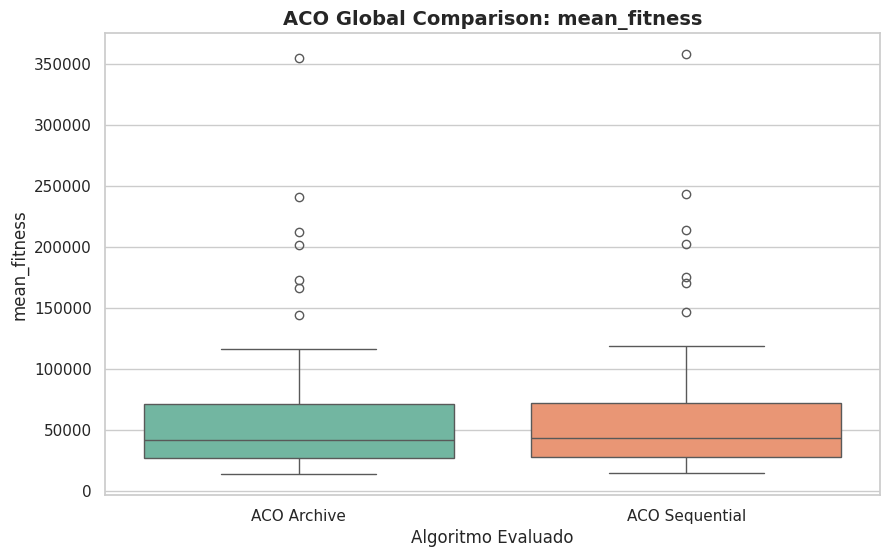

--- Test 1 vs 1 (Wilcoxon): ACO Archive vs ACO Sequential [mean_fitness] ---
Resultado: La diferencia ES estadísticamente significativa (p-value: 0.00000).
Veredicto: ACO Archive es superior a ACO Sequential.


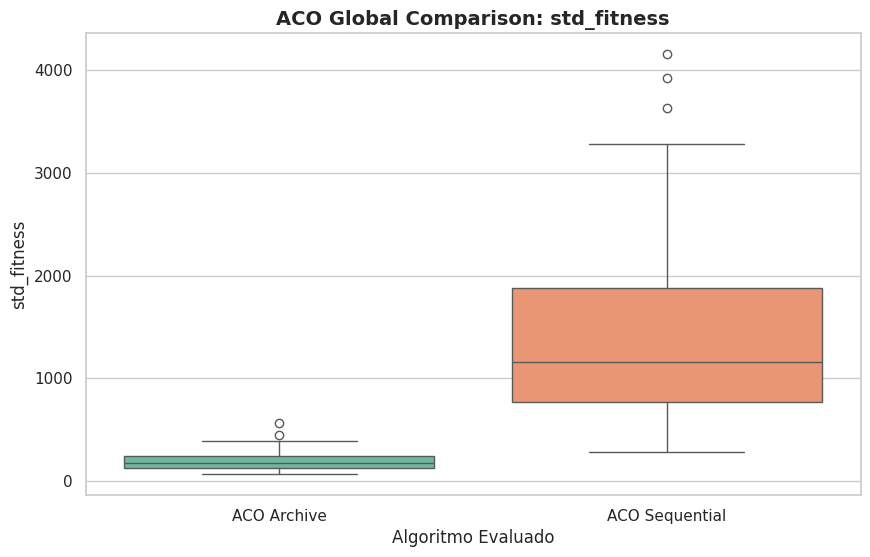

--- Test 1 vs 1 (Wilcoxon): ACO Archive vs ACO Sequential [std_fitness] ---
Resultado: La diferencia ES estadísticamente significativa (p-value: 0.00000).
Veredicto: ACO Archive es superior a ACO Sequential.


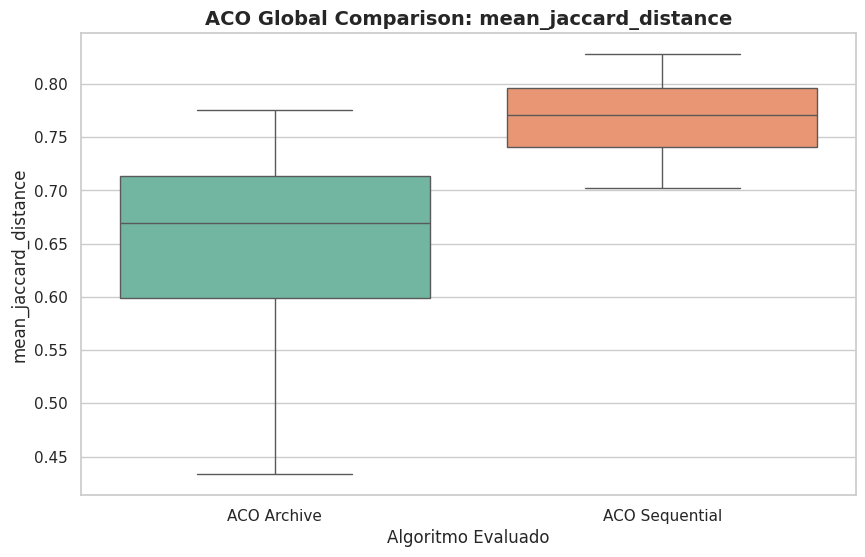

--- Test 1 vs 1 (Wilcoxon): ACO Archive vs ACO Sequential [mean_jaccard_distance] ---
Resultado: La diferencia ES estadísticamente significativa (p-value: 0.00000).
Veredicto: ACO Sequential es superior a ACO Archive.


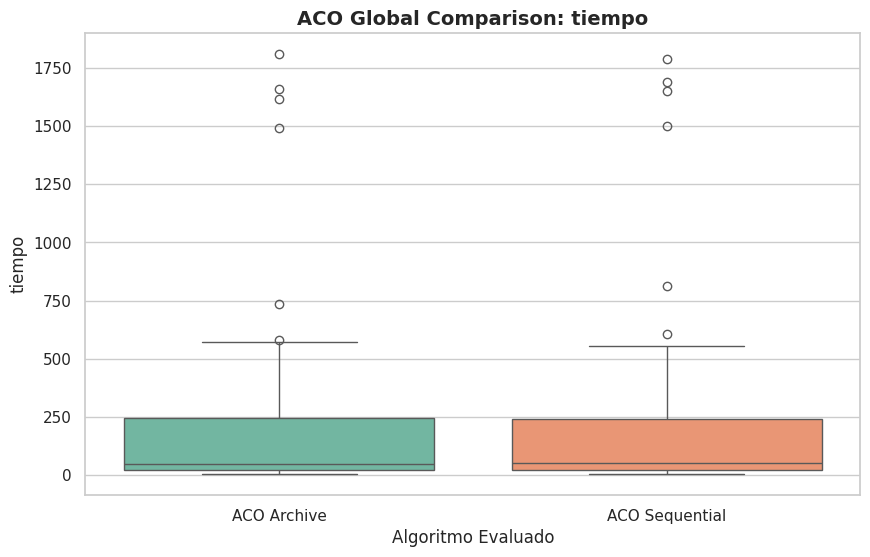

--- Test 1 vs 1 (Wilcoxon): ACO Archive vs ACO Sequential [tiempo] ---
Resultado: No hay evidencia estadística para afirmar que son distintos (p-value: 0.15018).


In [40]:
# Load the three ACO experiment folders
df_aco_archive = ExperimentLoader(os.path.join(results_aco_route, 'feasibility_archive')).experiment_data
df_aco_seq = ExperimentLoader(os.path.join(results_aco_route, 'feasibility_sequential')).experiment_data

# Add labels to distinguish the variants
df_aco_archive['algorithm'] = 'ACO Archive'
df_aco_seq['algorithm'] = 'ACO Sequential'

# Concatenate all results into a single global dataframe
df_aco_total = pd.concat([df_aco_archive, df_aco_seq], ignore_index=True)

# Instantiate your StatisticalAnalyzer class
aco_analyzer = StatisticalAnalyzer(df_aco_total)

# Define the metrics and their optimization goals
aco_metrics = {
    'mean_fitness': True, # Minimize fitness
    'std_fitness': True, # Minimize std
    'mean_jaccard_distance': False, # Maximize diversity
    'tiempo': True # Minimize time
}

# Run the full statistical battery for each metric
for metric, minimize in aco_metrics.items():
    
    # Plot the global Boxplot (medians per problem)
    aco_analyzer.dibujar_boxplot_global(
        metrica=metric, 
        titulo=f'ACO Global Comparison: {metric}'
    )
    
    # Execute 1 vs 1 test
    aco_analyzer.comparar_1_vs_1('ACO Archive', 'ACO Sequential', metric, es_minimizar=minimize)

### **Small conclusions**
Based on the rigorous statistical analysis performed using the Wilcoxon signed-rank test across the multi-problem dataset, we can draw the following definitive conclusions:

* **Superiority in Solution Quality and Stability:** The **Feasibility Archive ACO** is statistically superior (p < 0.05) to the Sequential variant in terms of minimizing the routing cost (`mean_fitness`). Furthermore, it demonstrates a significantly lower standard deviation (`std_fitness`), proving that the passive archive mechanism is not only more accurate but also far more robust and consistent across multiple stochastic executions.
* **Computational Efficiency and Effort:** The statistical tests reveal a technical tie in computational time (p = 0.15018). Both variants required the exact same number of evaluations and generations. The computational overhead of the Sequential method's active pheromone erasure proved to be negligible compared to the Archive's mathematical filtering, meaning both multimodal engines are equally fast.
* **The Role of Active Diversity:** As hypothesized, the statistical test confirms that the **Sequential ACO** maintains a significantly higher population diversity (`mean_jaccard_distance`, p < 0.05). However, given its inferior fitness results, this proves that the active destruction of the pheromone matrix (induced amnesia) forces the colony to explore sub-optimal regions. In contrast, the Archive approach sacrifices a degree of extreme diversity to heavily exploit the most promising, structurally valid routing zones, leading to better final solutions.

**Final Verdict:** The statistical evidence unequivocally proves that for CVRP optimization using Ant Colony logic, preserving the continuous evolution of the pheromone matrix while passively archiving structurally distinct solutions (Archive Method) is mathematically superior to active memory erasure (Sequential Method).

## **Final conclusions**
The comprehensive evaluation of the CVRP resolution through Ant Colony Optimization (ACO) variants provides a definitive roadmap of what works and what fails in bio-inspired routing optimization. This research moved from basic parameter tuning to the evaluation of complex multimodal memory structures, yielding the following insights:

1. **Constraint Handling is Paramount:** The most significant insight of this project is the overwhelming superiority of **Feasibility-based search** over Penalty-based methods. In ACO, where learning depends on the inverse of the cost, high-penalty "soft walls" destroy the feedback loop (Pheromone Starvation), proving that strict feasibility boundaries are the only viable path for swarm-based routing.
2. **The Impact of Heuristic Bias and Memory:** Our sensitivity analysis proved that ACO for the CVRP must be "greedy-led." The optimal **Balanced Profile** (a high heuristic weight ($\beta=3.0$), a moderate pheromone reliance ($\alpha=1.0$), and a controlled evaporation rate ($\rho=0.25$))consistently outperformed exploration-heavy setups. This suggests that the spatial information of the map is a highly reliable guide, while the 25% evaporation rate perfectly balances the fading of sub-optimal early trails with the consolidation of a strong collective memory.
3. **Comparative Algorithmic Performance:** The research benchmarked distinct multimodal philosophies:
    * **Sequential ACO (Active Memory Erasure):** Theoretically sound for guaranteeing structural diversity, but our rigorous non-parametric testing showed it suffers a permanent "convergence penalty." By continuously destroying the global optimum's pheromone trail, the swarm is forced into less efficient routes.
    * **Archive ACO (Passive Memory Filtration):** The definitive winner. It achieved the best solution quality (`mean_fitness`) and highest stability (`std_fitness`) across the entire dataset without requiring extra computation time.
4. **Diversity vs. Optimization:** Statistical analysis of the **Jaccard Distance** revealed that the Sequential variant maintains higher population diversity. However, this diversity is "unproductive," as it leads to inferior fitness. The Archive ACO intentionally focuses the swarm's energy on high-quality regions of the search space (Exploitation over Exploration) while relying on end-of-run mathematical filtering (Jaccard thresholding at 0.30) to extract contingency plans.
5. **Algorithmic Limitations:** No algorithm is perfect. While the Archive ACO is highly robust, all swarm variants show increased difficulty in scenarios with extreme node density. As the discrete search space grows exponentially, ensuring absolute precision in the final node sequences pushes the limits of pure swarm intelligence, highlighting the challenge of scaling pure ACO without massive computational resources.

**Final Summary Table**

| Feature | Sequential ACO | Archive ACO |
| :--- | :--- | :--- |
| **Solution Quality** | Good | **Excellent** |
| **Execution Speed** | Fast (Tie) | Fast (Tie) |
| **Stability (Std)** | Moderate | **High** |
| **Diversity (Jaccard)** | **Highest** | Moderate |
| **Swarm Learning** | Active (Erasure) | **Passive (Preserved)** |

**Final Verdict:** The integration of a feasibility-based passive archive transforms the ACO into a highly specialized and robust CVRP solver. The results unequivocally show that **respecting the natural evolution of pheromone trails** while applying **strict capacity boundaries** is the mathematically superior path for solving complex logistical constraints efficiently.